In [1]:
# MODELO 1: CHECK IN GENERAL:


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error
import pandas as pd
import numpy as np
from sklearn import tree

from sklearn.preprocessing import scale
import sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import r2_score, root_mean_squared_error

In [3]:
df = pd.read_csv("aflu_correct_modelar2.csv")
df

,datetime,active_flt_2h,new_flt_h,real_pax_checkin_adj,tot_pax,real_pax_passport,real_pax_seguridad,new_pax_passport,tot_capacity,tot_capacity_h,...,v_viento,estado_clima,festivo,pax_roll_sec_6h,pax_roll_mean_12h,lag_1,lag_2,lag_3,lag_6,lag_24
0,2025-11-17 04:00:00,9,9.0,355.610000,1590.0,162.375000,749.608333,373.0,1643,1643.0,...,9.7,1.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,2025-11-17 05:00:00,14,5.0,725.360000,706.0,147.471951,962.428862,0.0,2513,870.0,...,10.4,1.0,0,0.0,0.0,355.610000,NaN,NaN,NaN,NaN
2,2025-11-17 06:00:00,9,4.0,342.240000,709.0,131.853049,979.042886,0.0,1601,731.0,...,10.4,1.0,0,0.0,0.0,725.360000,355.610000,NaN,NaN,NaN
3,2025-11-17 07:00:00,21,17.0,959.440000,3038.0,458.250000,1966.966667,669.0,3997,3266.0,...,10.4,1.0,0,0.0,0.0,342.240000,725.360000,355.610000,NaN,NaN
4,2025-11-17 08:00:00,32,15.0,1817.000000,2819.0,817.154268,2873.841260,1074.0,6196,2930.0,...,10.1,1.0,0,0.0,0.0,959.440000,342.240000,725.360000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,2025-12-07 18:00:00,31,18.0,1555.430000,3401.0,894.370122,2659.526626,746.0,6132,3569.0,...,9.3,2.0,0,1763.0,1100.0,1432.053333,798.580000,723.120000,1100.081667,937.906667
381,2025-12-07 19:00:00,32,14.0,2093.353333,2645.0,850.865854,2980.045935,901.0,6330,2761.0,...,9.3,1.0,0,1988.0,1205.0,1555.430000,1432.053333,798.580000,1067.935000,723.910000
382,2025-12-07 20:00:00,17,3.0,1149.453333,636.0,531.184756,1618.443902,218.0,3419,658.0,...,11.1,1.0,0,2063.0,1132.0,2093.353333,1555.430000,1432.053333,687.470000,310.826667
383,2025-12-07 21:00:00,4,1.0,423.820000,181.0,238.171341,608.111992,181.0,847,189.0,...,11.1,1.0,0,1982.0,1072.0,1149.453333,2093.353333,1555.430000,723.120000,761.776667


In [4]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00,2025-11-17 09:00:00,2025-11-17 10:00:00,2025-11-17 11:00:00,2025-11-17 12:00:00,2025-11-17 13:00:00,...,2025-12-07 13:00:00,2025-12-07 14:00:00,2025-12-07 15:00:00,2025-12-07 16:00:00,2025-12-07 17:00:00,2025-12-07 18:00:00,2025-12-07 19:00:00,2025-12-07 20:00:00,2025-12-07 21:00:00,2025-12-07 22:00:00
active_flt_2h,9,14,9,21,32,24,18,23,23,14,...,20,13,12,20,26,31,32,17,4,1
new_flt_h,9.0,5.0,4.0,17.0,15.0,9.0,9.0,14.0,9.0,5.0,...,8.0,5.0,7.0,13.0,13.0,18.0,14.0,3.0,1.0,0.0
real_pax_checkin_adj,355.61,725.36,342.24,959.44,1817.0,1501.103333,952.926667,1149.14,1219.08,1006.776667,...,1067.935,687.47,723.12,798.58,1432.053333,1555.43,2093.353333,1149.453333,423.82,50.68
tot_pax,1590.0,706.0,709.0,3038.0,2819.0,1589.0,1602.0,2378.0,1586.0,984.0,...,1457.0,871.0,1243.0,2237.0,2467.0,3401.0,2645.0,636.0,181.0,0.0
real_pax_passport,162.375,147.471951,131.853049,458.25,817.154268,920.967683,619.432927,550.62622,662.285976,483.618293,...,269.935976,313.22561,436.739634,391.89939,767.633537,894.370122,850.865854,531.184756,238.171341,59.07439
real_pax_seguridad,749.608333,962.428862,979.042886,1966.966667,2873.84126,2050.306098,1528.814634,1965.466667,1823.413821,1469.823374,...,1631.914837,1169.496545,1094.45061,1699.583537,2324.939024,2659.526626,2980.045935,1618.443902,608.111992,122.284146
new_pax_passport,373.0,0.0,0.0,669.0,1074.0,698.0,536.0,1033.0,180.0,576.0,...,165.0,351.0,354.0,547.0,1122.0,746.0,901.0,218.0,181.0,0.0
tot_capacity,1643,2513,1601,3997,6196,4573,3360,4230,4172,2680,...,3680,2455,2195,3652,4932,6132,6330,3419,847,189
tot_capacity_h,1643.0,870.0,731.0,3266.0,2930.0,1643.0,1717.0,2513.0,1659.0,1021.0,...,1543.0,912.0,1283.0,2369.0,2563.0,3569.0,2761.0,658.0,189.0,0.0


In [5]:
df = df.drop(columns=['real_pax_passport', 'real_pax_seguridad', 'new_pax_passport','pax_roll_sec_6h',
             'pax_momentum_pas', 'Group_Ryanair_h', 'Group_easy_h', 'Group_wizz_h',
             'OCC_Ryanair', 'OCC_Easy', 'OCC_wizz', 'other_companies',
             'Group_easy', 'Group_wizz', 'festivo', 'pax_momentum_sec', 'Mean_OCC', 'pax_roll_mean_12h'])


In [6]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00,2025-11-17 09:00:00,2025-11-17 10:00:00,2025-11-17 11:00:00,2025-11-17 12:00:00,2025-11-17 13:00:00,...,2025-12-07 13:00:00,2025-12-07 14:00:00,2025-12-07 15:00:00,2025-12-07 16:00:00,2025-12-07 17:00:00,2025-12-07 18:00:00,2025-12-07 19:00:00,2025-12-07 20:00:00,2025-12-07 21:00:00,2025-12-07 22:00:00
active_flt_2h,9,14,9,21,32,24,18,23,23,14,...,20,13,12,20,26,31,32,17,4,1
new_flt_h,9.0,5.0,4.0,17.0,15.0,9.0,9.0,14.0,9.0,5.0,...,8.0,5.0,7.0,13.0,13.0,18.0,14.0,3.0,1.0,0.0
real_pax_checkin_adj,355.61,725.36,342.24,959.44,1817.0,1501.103333,952.926667,1149.14,1219.08,1006.776667,...,1067.935,687.47,723.12,798.58,1432.053333,1555.43,2093.353333,1149.453333,423.82,50.68
tot_pax,1590.0,706.0,709.0,3038.0,2819.0,1589.0,1602.0,2378.0,1586.0,984.0,...,1457.0,871.0,1243.0,2237.0,2467.0,3401.0,2645.0,636.0,181.0,0.0
tot_capacity,1643,2513,1601,3997,6196,4573,3360,4230,4172,2680,...,3680,2455,2195,3652,4932,6132,6330,3419,847,189
tot_capacity_h,1643.0,870.0,731.0,3266.0,2930.0,1643.0,1717.0,2513.0,1659.0,1021.0,...,1543.0,912.0,1283.0,2369.0,2563.0,3569.0,2761.0,658.0,189.0,0.0
pax_momentum,0.0,370.0,-383.0,617.0,858.0,-316.0,-548.0,196.0,70.0,-212.0,...,-32.0,-380.0,36.0,75.0,633.0,123.0,538.0,-944.0,-726.0,-373.0
pax_roll_mean_3h,0.0,0.0,474.0,676.0,1040.0,1426.0,1424.0,1201.0,1107.0,1125.0,...,1062.0,952.0,826.0,736.0,985.0,1262.0,1694.0,1599.0,1222.0,541.0
pax_roll_mean_6h,0.0,0.0,0.0,0.0,0.0,950.0,1050.0,1120.0,1266.0,1274.0,...,1195.0,973.0,902.0,899.0,968.0,1044.0,1215.0,1292.0,1242.0,1117.0


In [7]:
# DE MOMENTO NO LO PONGO, AL AÑADIR MÁS DATOS CON FESTIVO LO AÑADO

In [8]:
# tot_pax ES IMPORTANTE PERO CORRELACIONA MUCHO CON NUEVOS VUELOS X HORA 
# pax_roll_mean_3h correlaciona mucho con lag 1h 
df = df.drop(columns=['tot_capacity', 
                      'tot_capacity_h', 'EU_flt_h', 'INT_flt_h', 'NAC_flt_h', 
                      'new_flt_h', 'pax_roll_mean_3h', 'lluvia'])
# no ha llovido 'perc_no_checkin', 

In [9]:
df

,datetime,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,EU_flt,...,v_evening,v_night,temperatura,v_viento,estado_clima,lag_1,lag_2,lag_3,lag_6,lag_24
0,2025-11-17 04:00:00,9,355.610000,1590.0,0.0,0.0,7,6,3,7,...,0,0,10.5,9.7,1.0,NaN,NaN,NaN,NaN,NaN
1,2025-11-17 05:00:00,14,725.360000,706.0,370.0,0.0,10,11,3,9,...,0,0,10.0,10.4,1.0,355.610000,NaN,NaN,NaN,NaN
2,2025-11-17 06:00:00,9,342.240000,709.0,-383.0,0.0,5,9,0,6,...,0,0,9.6,10.4,1.0,725.360000,355.610000,NaN,NaN,NaN
3,2025-11-17 07:00:00,21,959.440000,3038.0,617.0,0.0,7,17,4,15,...,0,0,9.0,10.4,1.0,342.240000,725.360000,355.610000,NaN,NaN
4,2025-11-17 08:00:00,32,1817.000000,2819.0,858.0,0.0,12,21,11,20,...,0,0,9.9,10.1,1.0,959.440000,342.240000,725.360000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,2025-12-07 18:00:00,31,1555.430000,3401.0,123.0,1044.0,10,23,8,20,...,13,18,15.5,9.3,2.0,1432.053333,798.580000,723.120000,1100.081667,937.906667
381,2025-12-07 19:00:00,32,2093.353333,2645.0,538.0,1215.0,9,26,6,21,...,0,32,14.5,9.3,1.0,1555.430000,1432.053333,798.580000,1067.935000,723.910000
382,2025-12-07 20:00:00,17,1149.453333,636.0,-944.0,1292.0,5,16,1,10,...,0,17,13.5,11.1,1.0,2093.353333,1555.430000,1432.053333,687.470000,310.826667
383,2025-12-07 21:00:00,4,423.820000,181.0,-726.0,1242.0,2,4,0,2,...,0,4,13.1,11.1,1.0,1149.453333,2093.353333,1555.430000,723.120000,761.776667


In [10]:
df_mod = df.reset_index()

<Axes: >

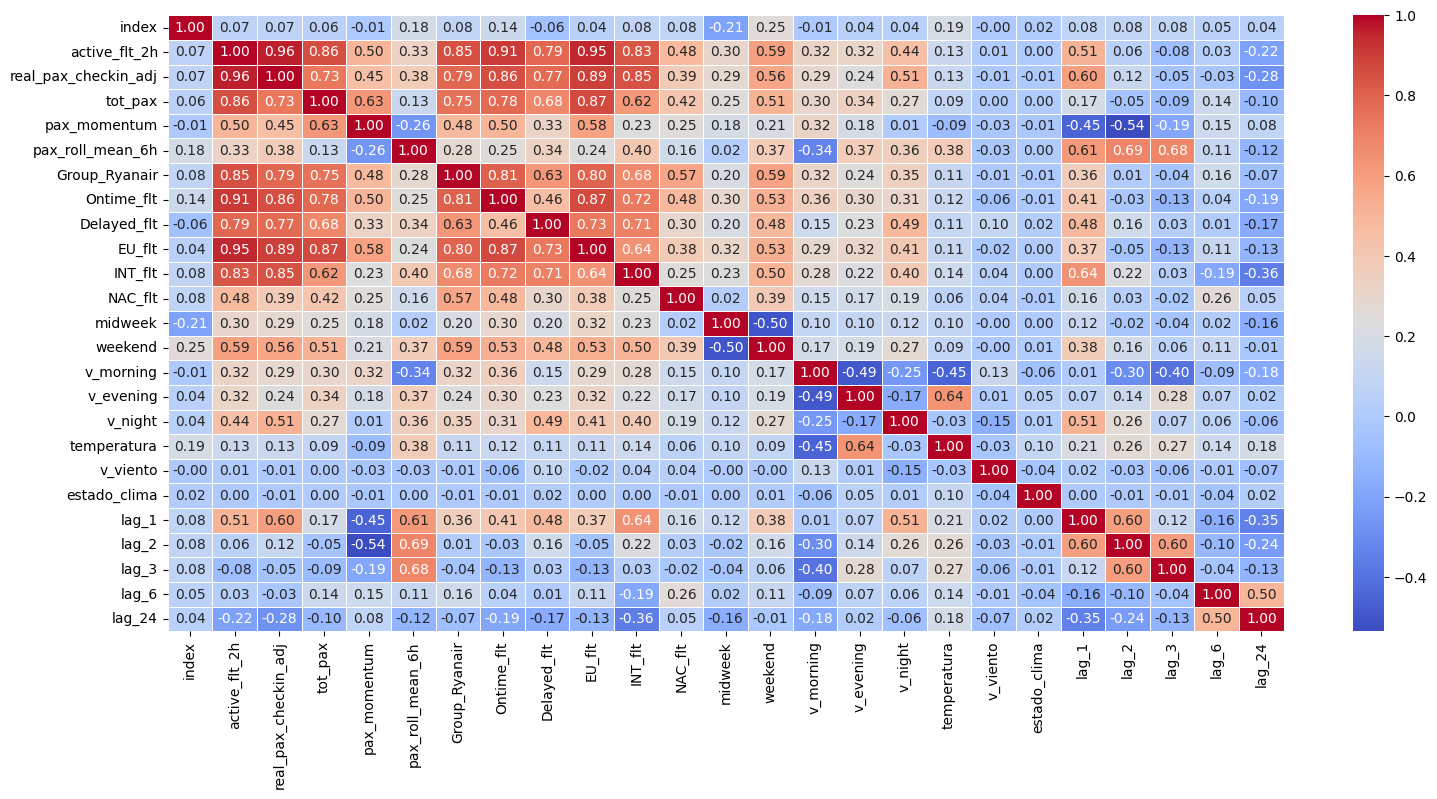

In [11]:
#A = df_mod.groupby("hora")["real_pax_checkin_adj"].sum().reset_index()
B = df_mod.drop(columns=['datetime'])
correlacion = B.corr()
plt.figure(figsize=(18,8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [12]:
# df = df.drop(columns=['festivo', 'real_pax_checkin', 'tot_capacity'])

In [13]:
#A = df_mod.drop(columns=['real_pax_checkin_adj'])

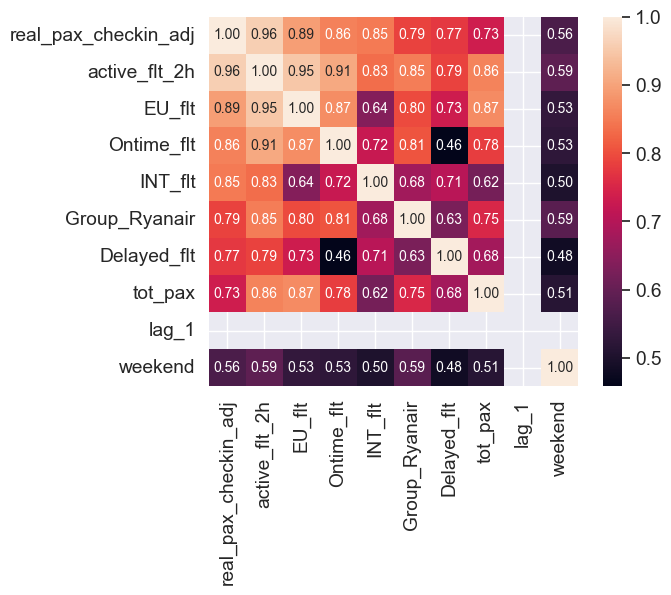

In [14]:
k = 10 #numero de variables
cols = correlacion.nlargest(k, 'real_pax_checkin_adj')['real_pax_checkin_adj'].index
cm = np.corrcoef(B[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [15]:
df_mod

,index,datetime,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,...,v_evening,v_night,temperatura,v_viento,estado_clima,lag_1,lag_2,lag_3,lag_6,lag_24
0,0,2025-11-17 04:00:00,9,355.610000,1590.0,0.0,0.0,7,6,3,...,0,0,10.5,9.7,1.0,NaN,NaN,NaN,NaN,NaN
1,1,2025-11-17 05:00:00,14,725.360000,706.0,370.0,0.0,10,11,3,...,0,0,10.0,10.4,1.0,355.610000,NaN,NaN,NaN,NaN
2,2,2025-11-17 06:00:00,9,342.240000,709.0,-383.0,0.0,5,9,0,...,0,0,9.6,10.4,1.0,725.360000,355.610000,NaN,NaN,NaN
3,3,2025-11-17 07:00:00,21,959.440000,3038.0,617.0,0.0,7,17,4,...,0,0,9.0,10.4,1.0,342.240000,725.360000,355.610000,NaN,NaN
4,4,2025-11-17 08:00:00,32,1817.000000,2819.0,858.0,0.0,12,21,11,...,0,0,9.9,10.1,1.0,959.440000,342.240000,725.360000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,2025-12-07 18:00:00,31,1555.430000,3401.0,123.0,1044.0,10,23,8,...,13,18,15.5,9.3,2.0,1432.053333,798.580000,723.120000,1100.081667,937.906667
381,381,2025-12-07 19:00:00,32,2093.353333,2645.0,538.0,1215.0,9,26,6,...,0,32,14.5,9.3,1.0,1555.430000,1432.053333,798.580000,1067.935000,723.910000
382,382,2025-12-07 20:00:00,17,1149.453333,636.0,-944.0,1292.0,5,16,1,...,0,17,13.5,11.1,1.0,2093.353333,1555.430000,1432.053333,687.470000,310.826667
383,383,2025-12-07 21:00:00,4,423.820000,181.0,-726.0,1242.0,2,4,0,...,0,4,13.1,11.1,1.0,1149.453333,2093.353333,1555.430000,723.120000,761.776667


In [16]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 385 non-null    int64  
 1   datetime              385 non-null    object 
 2   active_flt_2h         385 non-null    int64  
 3   real_pax_checkin_adj  385 non-null    float64
 4   tot_pax               385 non-null    float64
 5   pax_momentum          385 non-null    float64
 6   pax_roll_mean_6h      385 non-null    float64
 7   Group_Ryanair         385 non-null    int64  
 8   Ontime_flt            385 non-null    int64  
 9   Delayed_flt           385 non-null    int64  
 10  EU_flt                385 non-null    int64  
 11  INT_flt               385 non-null    int64  
 12  NAC_flt               385 non-null    int64  
 13  midweek               385 non-null    int64  
 14  weekend               385 non-null    int64  
 15  v_morning             3

In [17]:
df_mod['datetime']= pd.to_datetime(df_mod["datetime"])

In [18]:
df_mod["hora"] = df_mod["datetime"].dt.hour
df_mod["fecha"] = df_mod["datetime"].dt.date


In [19]:
df_mod

,index,datetime,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,...,temperatura,v_viento,estado_clima,lag_1,lag_2,lag_3,lag_6,lag_24,hora,fecha
0,0,2025-11-17 04:00:00,9,355.610000,1590.0,0.0,0.0,7,6,3,...,10.5,9.7,1.0,NaN,NaN,NaN,NaN,NaN,4,2025-11-17
1,1,2025-11-17 05:00:00,14,725.360000,706.0,370.0,0.0,10,11,3,...,10.0,10.4,1.0,355.610000,NaN,NaN,NaN,NaN,5,2025-11-17
2,2,2025-11-17 06:00:00,9,342.240000,709.0,-383.0,0.0,5,9,0,...,9.6,10.4,1.0,725.360000,355.610000,NaN,NaN,NaN,6,2025-11-17
3,3,2025-11-17 07:00:00,21,959.440000,3038.0,617.0,0.0,7,17,4,...,9.0,10.4,1.0,342.240000,725.360000,355.610000,NaN,NaN,7,2025-11-17
4,4,2025-11-17 08:00:00,32,1817.000000,2819.0,858.0,0.0,12,21,11,...,9.9,10.1,1.0,959.440000,342.240000,725.360000,NaN,NaN,8,2025-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,2025-12-07 18:00:00,31,1555.430000,3401.0,123.0,1044.0,10,23,8,...,15.5,9.3,2.0,1432.053333,798.580000,723.120000,1100.081667,937.906667,18,2025-12-07
381,381,2025-12-07 19:00:00,32,2093.353333,2645.0,538.0,1215.0,9,26,6,...,14.5,9.3,1.0,1555.430000,1432.053333,798.580000,1067.935000,723.910000,19,2025-12-07
382,382,2025-12-07 20:00:00,17,1149.453333,636.0,-944.0,1292.0,5,16,1,...,13.5,11.1,1.0,2093.353333,1555.430000,1432.053333,687.470000,310.826667,20,2025-12-07
383,383,2025-12-07 21:00:00,4,423.820000,181.0,-726.0,1242.0,2,4,0,...,13.1,11.1,1.0,1149.453333,2093.353333,1555.430000,723.120000,761.776667,21,2025-12-07


In [20]:
df_mod[(df_mod['datetime'] == '2025-11-30 04:00:00')]

,index,datetime,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,...,temperatura,v_viento,estado_clima,lag_1,lag_2,lag_3,lag_6,lag_24,hora,fecha
237,237,2025-11-30 04:00:00,7,276.27,1237.0,123.0,712.0,6,7,0,...,8.0,9.0,2.0,153.166667,786.236667,1094.083333,863.336667,1059.32,4,2025-11-30


In [21]:
# OBSERVACION EL LAG NO ES 0 , NORMALMENTE Y POR LOGICA A LAS 3 DE LA MAÑANA NO HAY 
# AFLUENCIA Y MOVIMIENTO EL COGE LO QUE HA PASADO A LAS 22 

In [22]:
df_plot = df_mod.groupby("hora")[["real_pax_checkin_adj", 
"lag_1", "lag_2", "lag_3", "lag_6", "lag_24"]].mean().reset_index()


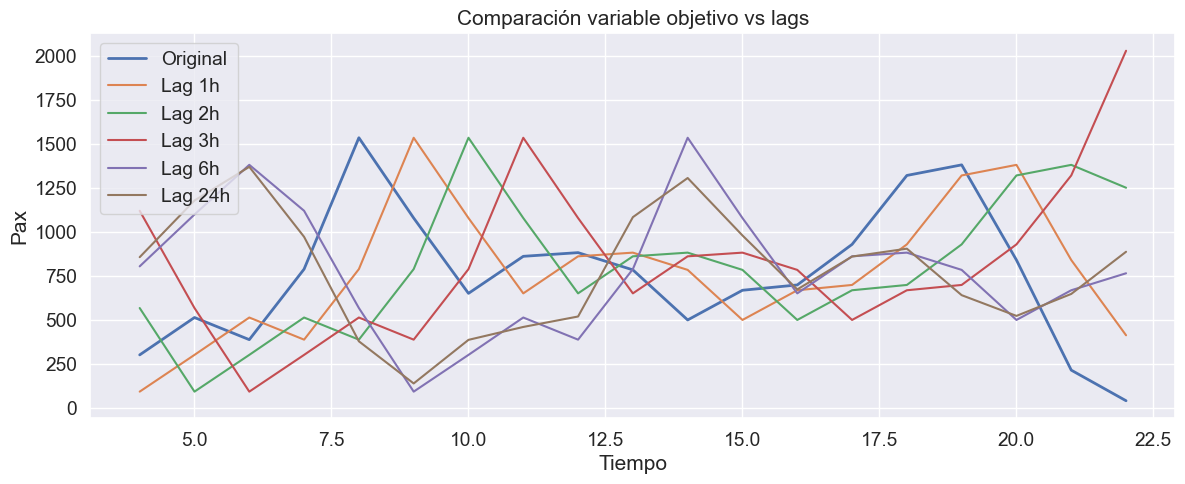

In [23]:
plt.figure(figsize=(14,5))
plt.plot(df_plot["hora"], df_plot["real_pax_checkin_adj"], label="Original", linewidth=2)
plt.plot(df_plot["hora"], df_plot["lag_1"], label="Lag 1h")
plt.plot(df_plot["hora"], df_plot["lag_2"], label="Lag 2h")
plt.plot(df_plot["hora"], df_plot["lag_3"], label="Lag 3h")
plt.plot(df_plot["hora"], df_plot["lag_6"], label="Lag 6h")
plt.plot(df_plot["hora"], df_plot["lag_24"], label="Lag 24h")
plt.title("Comparación variable objetivo vs lags")
plt.xlabel("Tiempo")
plt.ylabel("Pax")
plt.legend()
plt.grid(True)
plt.show()


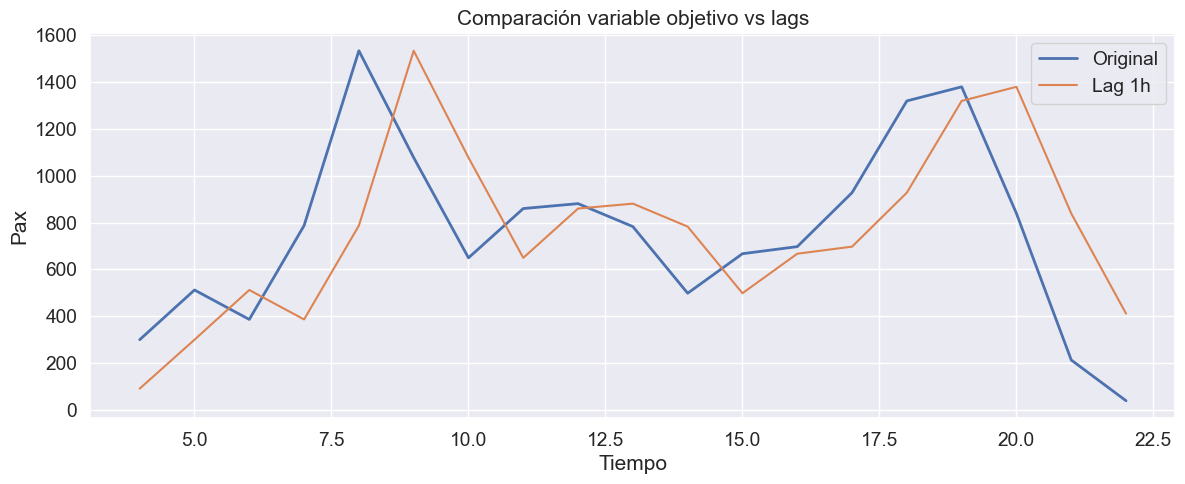

In [24]:
plt.figure(figsize=(14,5))
plt.plot(df_plot["hora"], df_plot["real_pax_checkin_adj"], label="Original", linewidth=2)
plt.plot(df_plot["hora"], df_plot["lag_1"], label="Lag 1h")

plt.title("Comparación variable objetivo vs lags")
plt.xlabel("Tiempo")
plt.ylabel("Pax")
plt.legend()
plt.grid(True)
plt.show()


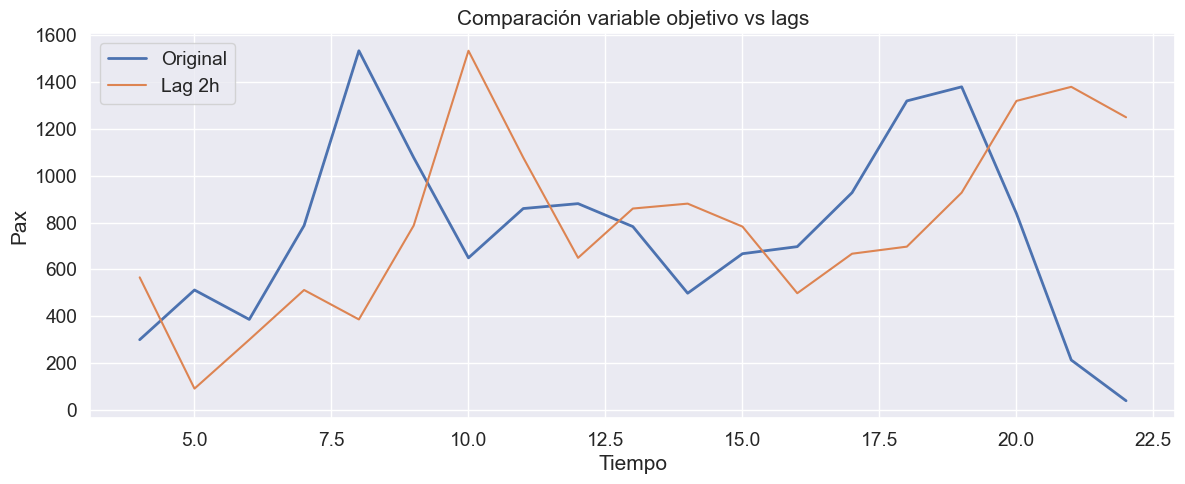

In [25]:
plt.figure(figsize=(14,5))
plt.plot(df_plot["hora"], df_plot["real_pax_checkin_adj"], label="Original", linewidth=2)
plt.plot(df_plot["hora"], df_plot["lag_2"], label="Lag 2h")

plt.title("Comparación variable objetivo vs lags")
plt.xlabel("Tiempo")
plt.ylabel("Pax")
plt.legend()
plt.grid(True)
plt.show()


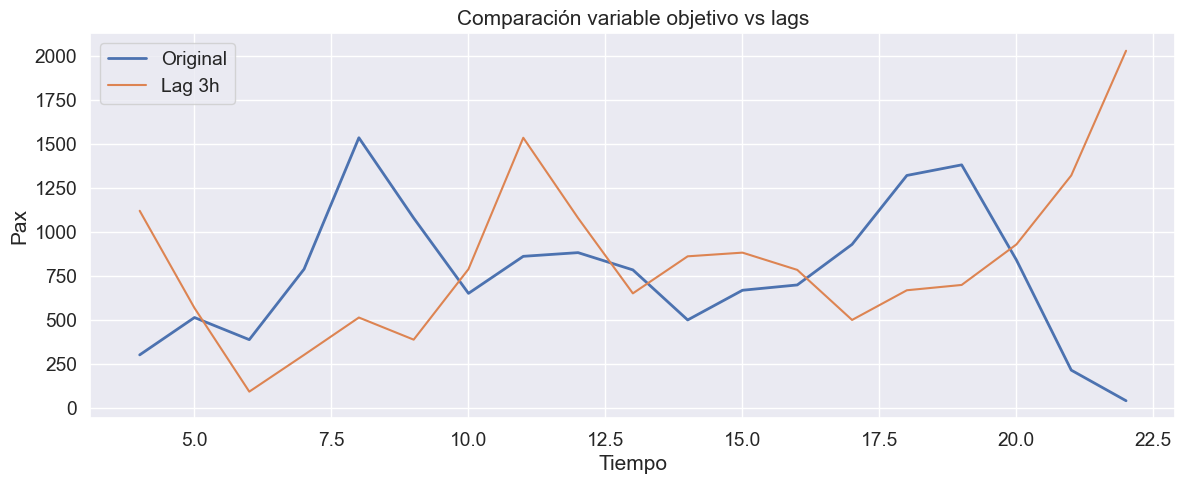

In [26]:
plt.figure(figsize=(14,5))
plt.plot(df_plot["hora"], df_plot["real_pax_checkin_adj"], label="Original", linewidth=2)
plt.plot(df_plot["hora"], df_plot["lag_3"], label="Lag 3h")

plt.title("Comparación variable objetivo vs lags")
plt.xlabel("Tiempo")
plt.ylabel("Pax")
plt.legend()
plt.grid(True)
plt.show()


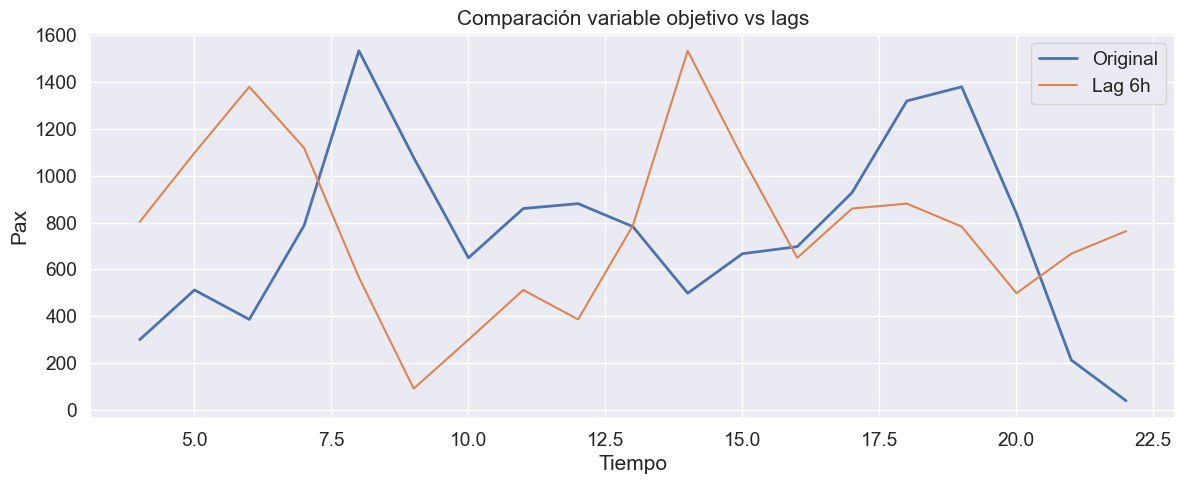

In [27]:
plt.figure(figsize=(14,5))
plt.plot(df_plot["hora"], df_plot["real_pax_checkin_adj"], label="Original", linewidth=2)
plt.plot(df_plot["hora"], df_plot["lag_6"], label="Lag 6h")

plt.title("Comparación variable objetivo vs lags")
plt.xlabel("Tiempo")
plt.ylabel("Pax")
plt.legend()
plt.grid(True)
plt.show()


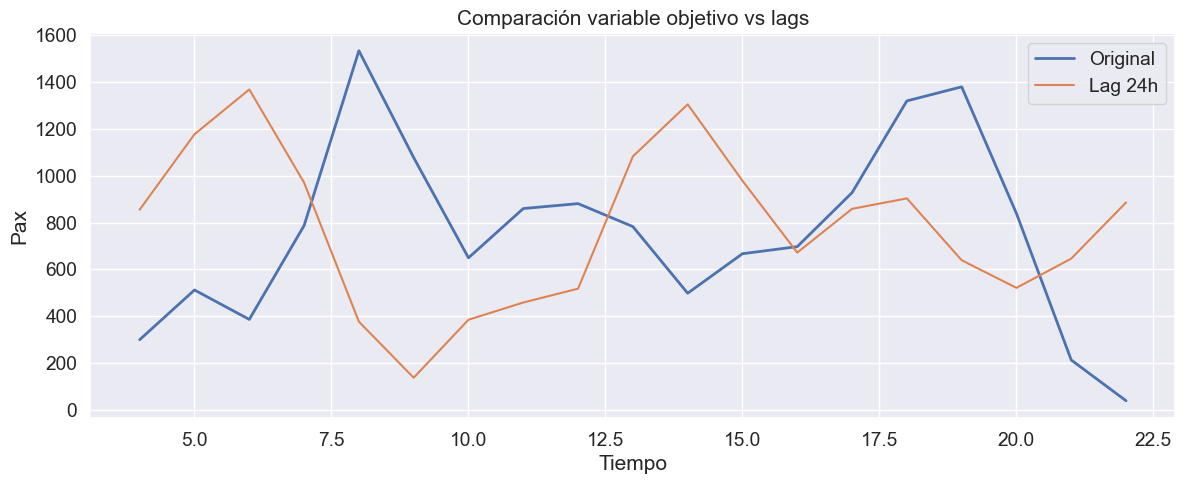

In [28]:
plt.figure(figsize=(14,5))
plt.plot(df_plot["hora"], df_plot["real_pax_checkin_adj"], label="Original", linewidth=2)
plt.plot(df_plot["hora"], df_plot["lag_24"], label="Lag 24h")

plt.title("Comparación variable objetivo vs lags")
plt.xlabel("Tiempo")
plt.ylabel("Pax")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
df_mod = df_mod.drop(columns=['lag_1', 'lag_2', 'lag_3', 'lag_6','lag_24'])

## MODELO

In [30]:
df_mod.isna().sum()

index                   0
datetime                0
active_flt_2h           0
real_pax_checkin_adj    0
tot_pax                 0
pax_momentum            0
pax_roll_mean_6h        0
Group_Ryanair           0
Ontime_flt              0
Delayed_flt             0
EU_flt                  0
INT_flt                 0
NAC_flt                 0
midweek                 0
weekend                 0
v_morning               0
v_evening               0
v_night                 0
temperatura             0
v_viento                0
estado_clima            0
hora                    0
fecha                   0
dtype: int64

In [31]:
df_mod.T

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
index,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00,2025-11-17 09:00:00,2025-11-17 10:00:00,2025-11-17 11:00:00,2025-11-17 12:00:00,2025-11-17 13:00:00,...,2025-12-07 13:00:00,2025-12-07 14:00:00,2025-12-07 15:00:00,2025-12-07 16:00:00,2025-12-07 17:00:00,2025-12-07 18:00:00,2025-12-07 19:00:00,2025-12-07 20:00:00,2025-12-07 21:00:00,2025-12-07 22:00:00
active_flt_2h,9,14,9,21,32,24,18,23,23,14,...,20,13,12,20,26,31,32,17,4,1
real_pax_checkin_adj,355.61,725.36,342.24,959.44,1817.0,1501.103333,952.926667,1149.14,1219.08,1006.776667,...,1067.935,687.47,723.12,798.58,1432.053333,1555.43,2093.353333,1149.453333,423.82,50.68
tot_pax,1590.0,706.0,709.0,3038.0,2819.0,1589.0,1602.0,2378.0,1586.0,984.0,...,1457.0,871.0,1243.0,2237.0,2467.0,3401.0,2645.0,636.0,181.0,0.0
pax_momentum,0.0,370.0,-383.0,617.0,858.0,-316.0,-548.0,196.0,70.0,-212.0,...,-32.0,-380.0,36.0,75.0,633.0,123.0,538.0,-944.0,-726.0,-373.0
pax_roll_mean_6h,0.0,0.0,0.0,0.0,0.0,950.0,1050.0,1120.0,1266.0,1274.0,...,1195.0,973.0,902.0,899.0,968.0,1044.0,1215.0,1292.0,1242.0,1117.0
Group_Ryanair,7,10,5,7,12,11,8,9,6,3,...,8,8,9,10,10,10,9,5,2,1
Ontime_flt,6,11,9,17,21,16,14,14,12,8,...,20,13,11,17,21,23,26,16,4,1
Delayed_flt,3,3,0,4,11,8,4,9,11,6,...,0,0,1,3,5,8,6,1,0,0


In [32]:
import skforecast
print(skforecast.__version__)

0.14.0


In [33]:
# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots # resetear graficos 
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10

# Modeling and Forecasting
# ==============================================================================
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster
# pre procesador 
from skforecast.preprocessing import RollingFeatures
from skforecast.utils import save_forecaster
from skforecast.utils import load_forecaster
import shap


import warnings
warnings.filterwarnings('once')
warnings.filterwarnings("ignore", category=DeprecationWarning)

color = '\033[1m\033[38;5;208m' 
print(f"{color}Version skforecast: {skforecast.__version__}")
print(f"{color}Version scikit-learn: {sklearn.__version__}")
print(f"{color}Version pandas: {pd.__version__}")
print(f"{color}Version numpy: {np.__version__}")

C:\Users\linap\anaconda3\envs\skf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Version skforecast: 0.14.0
Version scikit-learn: 1.7.2
Version pandas: 2.3.3
Version numpy: 2.2.6


In [34]:
# si tiene estas fechas es finde semana
"""
weekend_days = [
    pd.to_datetime("2025-11-21").date(),
    pd.to_datetime("2025-11-22").date(),
    pd.to_datetime("2025-11-23").date(),
    pd.to_datetime("2025-11-28").date(),
    pd.to_datetime("2025-11-29").date(),
    pd.to_datetime("2025-11-30").date(),
]

df_mod["is_weekend"] = df_mod["fecha"].isin(weekend_days).astype(int)

df_mod["is_midweek"] = (df_mod["is_weekend"] == 0).astype(int)
"""

# Si la variable ontime es diferente a 0 indicar 1 
#df_mod["is_Ontime"] = (df_mod["Ontime_flt"] != 0).astype(int)
# Si la variable delay es diferente a 0 indicar 1 
#df_mod["is_Delayed"] = (df_mod["Delayed_flt"] != 0).astype(int)
#df_mod["is_midweek"] = (df_mod["is_weekend"] == 0).astype(int)
#df_mod['fecha'] = pd.to_datetime(df_mod['fecha'], errors="coerce")
#df_mod["weekday"] = df_mod["fecha"].dt.weekday  # 0–6
#df_mod["is_weekend"] = df_mod["weekday"].isin([4, 6]).astype(int)

#df_mod["is_morning"] = df_mod["hora"].between(4,11).astype(int)
#df_mod["is_evening"] = df_mod["hora"].between(12,18).astype(int)
#df_mod["is_night"] = (df_mod["hora"].between(19, 23) | df_mod["hora"].between(0, 3)).astype(int)
# ONTIME Y DELAY 
#df_mod = df_mod.drop(columns=['weekend', 'midweek', 'v_morning', 'v_evening', 'v_night'])

'\nweekend_days = [\n    pd.to_datetime("2025-11-21").date(),\n    pd.to_datetime("2025-11-22").date(),\n    pd.to_datetime("2025-11-23").date(),\n    pd.to_datetime("2025-11-28").date(),\n    pd.to_datetime("2025-11-29").date(),\n    pd.to_datetime("2025-11-30").date(),\n]\n\ndf_mod["is_weekend"] = df_mod["fecha"].isin(weekend_days).astype(int)\n\ndf_mod["is_midweek"] = (df_mod["is_weekend"] == 0).astype(int)\n'

In [35]:
df_mod

,index,datetime,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
0,0,2025-11-17 04:00:00,9,355.610000,1590.0,0.0,0.0,7,6,3,...,9,0,9,0,0,10.5,9.7,1.0,4,2025-11-17
1,1,2025-11-17 05:00:00,14,725.360000,706.0,370.0,0.0,10,11,3,...,14,0,14,0,0,10.0,10.4,1.0,5,2025-11-17
2,2,2025-11-17 06:00:00,9,342.240000,709.0,-383.0,0.0,5,9,0,...,9,0,9,0,0,9.6,10.4,1.0,6,2025-11-17
3,3,2025-11-17 07:00:00,21,959.440000,3038.0,617.0,0.0,7,17,4,...,21,0,21,0,0,9.0,10.4,1.0,7,2025-11-17
4,4,2025-11-17 08:00:00,32,1817.000000,2819.0,858.0,0.0,12,21,11,...,32,0,32,0,0,9.9,10.1,1.0,8,2025-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,2025-12-07 18:00:00,31,1555.430000,3401.0,123.0,1044.0,10,23,8,...,0,31,0,13,18,15.5,9.3,2.0,18,2025-12-07
381,381,2025-12-07 19:00:00,32,2093.353333,2645.0,538.0,1215.0,9,26,6,...,0,32,0,0,32,14.5,9.3,1.0,19,2025-12-07
382,382,2025-12-07 20:00:00,17,1149.453333,636.0,-944.0,1292.0,5,16,1,...,0,17,0,0,17,13.5,11.1,1.0,20,2025-12-07
383,383,2025-12-07 21:00:00,4,423.820000,181.0,-726.0,1242.0,2,4,0,...,0,4,0,0,4,13.1,11.1,1.0,21,2025-12-07


In [36]:
df_mod = df_mod.set_index("datetime")
#df_mod = df_mod.drop(columns=['hora', 'fecha'])
df_mod = df_mod.asfreq("h")
num_cols = [
    'real_pax_checkin_adj', 'active_flt_2h', 'tot_pax', 'pax_momentum',
    'pax_roll_mean_6h', 'EU_flt', 'INT_flt', 'NAC_flt', 'Delayed_flt',
    'Ontime_flt', 'Group_Ryanair'
]

df_mod[num_cols] = df_mod[num_cols].fillna(0)

df_mod = df_mod.sort_index()
df_mod

,index,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,EU_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
datetime,,,,,,,,,,,,,,,,,,,,,
2025-11-17 04:00:00,0.0,9.0,355.610000,1590.0,0.0,0.0,7.0,6.0,3.0,7.0,...,9.0,0.0,9.0,0.0,0.0,10.5,9.7,1.0,4.0,2025-11-17
2025-11-17 05:00:00,1.0,14.0,725.360000,706.0,370.0,0.0,10.0,11.0,3.0,9.0,...,14.0,0.0,14.0,0.0,0.0,10.0,10.4,1.0,5.0,2025-11-17
2025-11-17 06:00:00,2.0,9.0,342.240000,709.0,-383.0,0.0,5.0,9.0,0.0,6.0,...,9.0,0.0,9.0,0.0,0.0,9.6,10.4,1.0,6.0,2025-11-17
2025-11-17 07:00:00,3.0,21.0,959.440000,3038.0,617.0,0.0,7.0,17.0,4.0,15.0,...,21.0,0.0,21.0,0.0,0.0,9.0,10.4,1.0,7.0,2025-11-17
2025-11-17 08:00:00,4.0,32.0,1817.000000,2819.0,858.0,0.0,12.0,21.0,11.0,20.0,...,32.0,0.0,32.0,0.0,0.0,9.9,10.1,1.0,8.0,2025-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-07 18:00:00,380.0,31.0,1555.430000,3401.0,123.0,1044.0,10.0,23.0,8.0,20.0,...,0.0,31.0,0.0,13.0,18.0,15.5,9.3,2.0,18.0,2025-12-07
2025-12-07 19:00:00,381.0,32.0,2093.353333,2645.0,538.0,1215.0,9.0,26.0,6.0,21.0,...,0.0,32.0,0.0,0.0,32.0,14.5,9.3,1.0,19.0,2025-12-07
2025-12-07 20:00:00,382.0,17.0,1149.453333,636.0,-944.0,1292.0,5.0,16.0,1.0,10.0,...,0.0,17.0,0.0,0.0,17.0,13.5,11.1,1.0,20.0,2025-12-07


In [37]:
clima_cols = ['v_viento', 'estado_clima', 'temperatura']
df_mod[clima_cols] = df_mod[clima_cols].ffill()

In [38]:
df_mod.head(30)

,index,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,EU_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
datetime,,,,,,,,,,,,,,,,,,,,,
2025-11-17 04:00:00,0.0,9.0,355.610000,1590.0,0.0,0.0,7.0,6.0,3.0,7.0,...,9.0,0.0,9.0,0.0,0.0,10.5,9.7,1.0,4.0,2025-11-17
2025-11-17 05:00:00,1.0,14.0,725.360000,706.0,370.0,0.0,10.0,11.0,3.0,9.0,...,14.0,0.0,14.0,0.0,0.0,10.0,10.4,1.0,5.0,2025-11-17
2025-11-17 06:00:00,2.0,9.0,342.240000,709.0,-383.0,0.0,5.0,9.0,0.0,6.0,...,9.0,0.0,9.0,0.0,0.0,9.6,10.4,1.0,6.0,2025-11-17
2025-11-17 07:00:00,3.0,21.0,959.440000,3038.0,617.0,0.0,7.0,17.0,4.0,15.0,...,21.0,0.0,21.0,0.0,0.0,9.0,10.4,1.0,7.0,2025-11-17
2025-11-17 08:00:00,4.0,32.0,1817.000000,2819.0,858.0,0.0,12.0,21.0,11.0,20.0,...,32.0,0.0,32.0,0.0,0.0,9.9,10.1,1.0,8.0,2025-11-17
2025-11-17 09:00:00,5.0,24.0,1501.103333,1589.0,-316.0,950.0,11.0,16.0,8.0,14.0,...,24.0,0.0,24.0,0.0,0.0,12.5,7.6,1.0,9.0,2025-11-17
2025-11-17 10:00:00,6.0,18.0,952.926667,1602.0,-548.0,1050.0,8.0,14.0,4.0,10.0,...,18.0,0.0,9.0,9.0,0.0,15.1,6.1,1.0,10.0,2025-11-17
2025-11-17 11:00:00,7.0,23.0,1149.140000,2378.0,196.0,1120.0,9.0,14.0,9.0,13.0,...,23.0,0.0,0.0,23.0,0.0,16.6,6.8,3.0,11.0,2025-11-17
2025-11-17 12:00:00,8.0,23.0,1219.080000,1586.0,70.0,1266.0,6.0,12.0,11.0,15.0,...,23.0,0.0,0.0,23.0,0.0,17.2,7.6,3.0,12.0,2025-11-17


In [39]:
#df_mod['Mean_OCC'] = df_mod['Mean_OCC'].fillna(0) # PUNTUAL, SOLO PORQUE LA NECESITO
# NO HAY VUELOS CUANDO NO HAY OCUPACIÓN FACILITAR EL ENTENDIMIENTO AL MODELO
# CREANDO UNA VARIABLE QUE LE INDIQUE QUE ES 0 PORQUE NO HAY VUELO. 
df_mod["no_vuelos"] = (df_mod["active_flt_2h"] == 0).astype(int)


In [40]:
# 
df_mod['fecha'] = pd.to_datetime(df_mod['fecha'], errors="coerce")
#df_mod["weekday"] = df_mod["fecha"].dt.weekday  # 0–6
#df_mod["is_weekend"] = df_mod["weekday"].isin([4, 6]).astype(int)
df_mod["weekday_num"] = df_mod.index.weekday      # 0–6
df_mod["is_weekend"] = df_mod["weekday_num"].isin([5,6]).astype(int)
df_mod["is_weekday"] = (df_mod["is_weekend"] == 0).astype(int)

# DUMMIES TEMPORALES 
df_mod["h"] = df_mod.index.hour

df_mod["is_morning"] = df_mod["h"].between(4,11).astype(int)
df_mod["is_evening"] = df_mod["h"].between(12,18).astype(int)
df_mod["is_night"] = (
    (df_mod["h"] >= 19) | (df_mod["h"] <= 3)
).astype(int)

# ONTIME Y DELAY 
df_mod = df_mod.drop(columns=['weekend', 'midweek', 'v_morning', 'v_evening', 'v_night'])

In [41]:
df_mod["index"] = np.arange(len(df_mod)) # reestablecer indice correcto 

In [42]:
df_fest = pd.read_csv("festividades_bcn.csv")
df_fest["Date_holiday"] = pd.to_datetime(df_fest["Date_holiday"]).dt.date
df_mod["festivo"] = df_mod["fecha"].isin(df_fest["Date_holiday"]).astype(int)
df_mod["Visp_fest"] = df_mod["fecha"].isin(df_fest["holiday_eve"]).astype(int)
# devuelve True si la fecha está en la tabla de festivos. 

C:\Users\linap\AppData\Local\Temp\ipykernel_4024\3300672883.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_mod["festivo"] = df_mod["fecha"].isin(df_fest["Date_holiday"]).astype(int)
C:\Users\linap\AppData\Local\Temp\ipykernel_4024\3300672883.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_mod["Visp_fest"] = df_mod["fecha"].isin(df_fest["holiday_eve"]).astype(int)


In [43]:
df_mod = df_mod.drop(columns=['fecha', 'hora'])

In [44]:
df_mod.isna().sum()

index                   0
active_flt_2h           0
real_pax_checkin_adj    0
tot_pax                 0
pax_momentum            0
pax_roll_mean_6h        0
Group_Ryanair           0
Ontime_flt              0
Delayed_flt             0
EU_flt                  0
INT_flt                 0
NAC_flt                 0
temperatura             0
v_viento                0
estado_clima            0
no_vuelos               0
weekday_num             0
is_weekend              0
is_weekday              0
h                       0
is_morning              0
is_evening              0
is_night                0
festivo                 0
Visp_fest               0
dtype: int64

<Axes: >

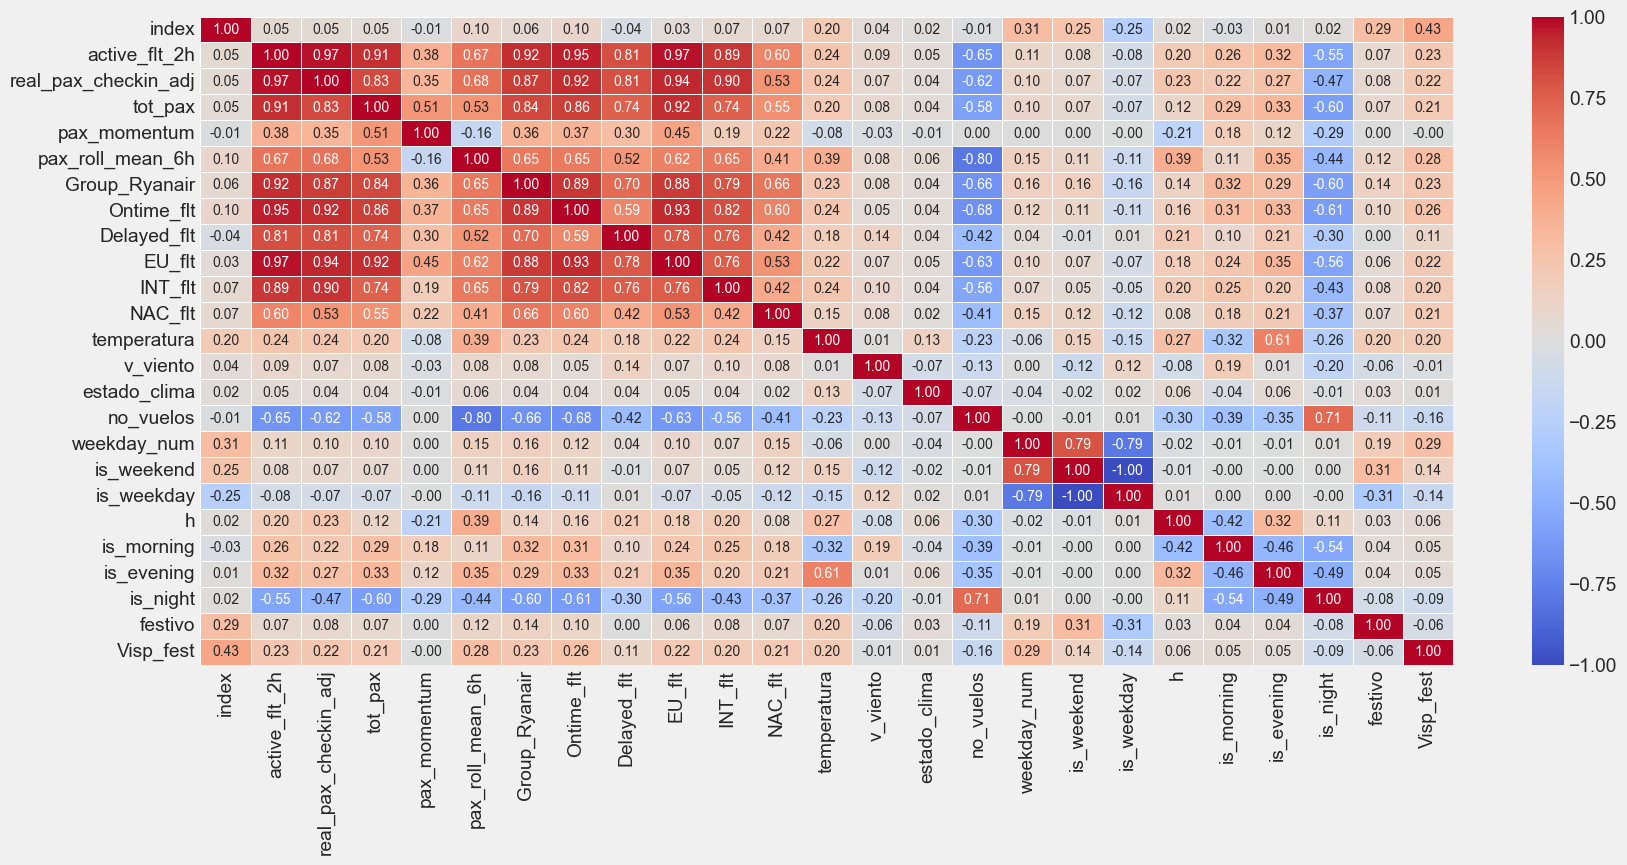

In [45]:
### B = df_mod.drop(columns=['datetime'])
correlacion = df_mod.corr()
plt.figure(figsize=(18,8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

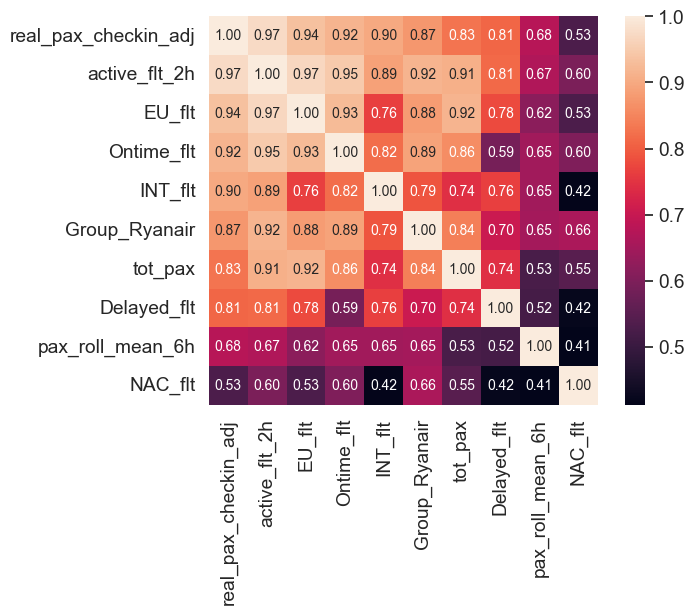

In [46]:
k = 10 #numero de variables
cols = correlacion.nlargest(k, 'real_pax_checkin_adj')['real_pax_checkin_adj'].index
cm = np.corrcoef(df_mod[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [47]:
# AÑADIR ONTIME Y DELAY COMO BINARIO
# RELLENAR NANS SEGUN TIPO DE VARIABLE O POR VAR PREVIA O POR 0 

In [48]:
print(f'Número de filas con missing values: {df_mod.isnull().any(axis=1).mean()}')

Número de filas con missing values: 0.0


In [49]:
df_mod.tail(66)

,index,active_flt_2h,real_pax_checkin_adj,tot_pax,pax_momentum,pax_roll_mean_6h,Group_Ryanair,Ontime_flt,Delayed_flt,EU_flt,...,no_vuelos,weekday_num,is_weekend,is_weekday,h,is_morning,is_evening,is_night,festivo,Visp_fest
datetime,,,,,,,,,,,,,,,,,,,,,
2025-12-05 05:00:00,433,10.0,565.083333,468.0,250.0,769.0,7.0,10.0,0.0,7.0,...,0,4,0,1,5,1,0,0,0,1
2025-12-05 06:00:00,434,10.0,501.203333,1246.0,-64.0,634.0,5.0,9.0,1.0,6.0,...,0,4,0,1,6,1,0,0,0,1
2025-12-05 07:00:00,435,23.0,992.546667,3013.0,491.0,564.0,9.0,19.0,4.0,14.0,...,0,4,0,1,7,1,0,0,0,1
2025-12-05 08:00:00,436,31.0,2048.740000,2837.0,1056.0,767.0,10.0,21.0,10.0,16.0,...,0,4,0,1,8,1,0,0,0,1
2025-12-05 09:00:00,437,27.0,1401.348333,2098.0,-647.0,971.0,12.0,18.0,9.0,15.0,...,0,4,0,1,9,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-07 18:00:00,494,31.0,1555.430000,3401.0,123.0,1044.0,10.0,23.0,8.0,20.0,...,0,6,1,0,18,0,1,0,0,1
2025-12-07 19:00:00,495,32.0,2093.353333,2645.0,538.0,1215.0,9.0,26.0,6.0,21.0,...,0,6,1,0,19,0,0,1,0,1
2025-12-07 20:00:00,496,17.0,1149.453333,636.0,-944.0,1292.0,5.0,16.0,1.0,10.0,...,0,6,1,0,20,0,0,1,0,1


In [50]:
df_mod= df_mod.drop(columns=['h'])

In [51]:
df_mod.to_csv("Tabla_modelo_checkin.csv")

In [52]:
# df['OCC'] = df['OCC'].fillna(0)
# df["no_vuelos"] = (df["new_flt_h"] == 0).astype(int)

In [53]:
# PROBAR CON XGBOOST QUE MANEJA NANS, DEPENDE METRICA VOLVER A GESTIONAR NANS 

In [54]:
(df_mod.index == pd.date_range(
                    start = df_mod.index.min(),
                    end   = df_mod.index.max(),
                    freq  = df_mod.index.freq)
).all()

np.True_

Fechas train : 2025-11-17 04:00:00 --- 2025-12-06 08:00:00  (n=461)
Fechas test  : 2025-12-06 09:00:00 --- 2025-12-07 22:00:00  (n=38)


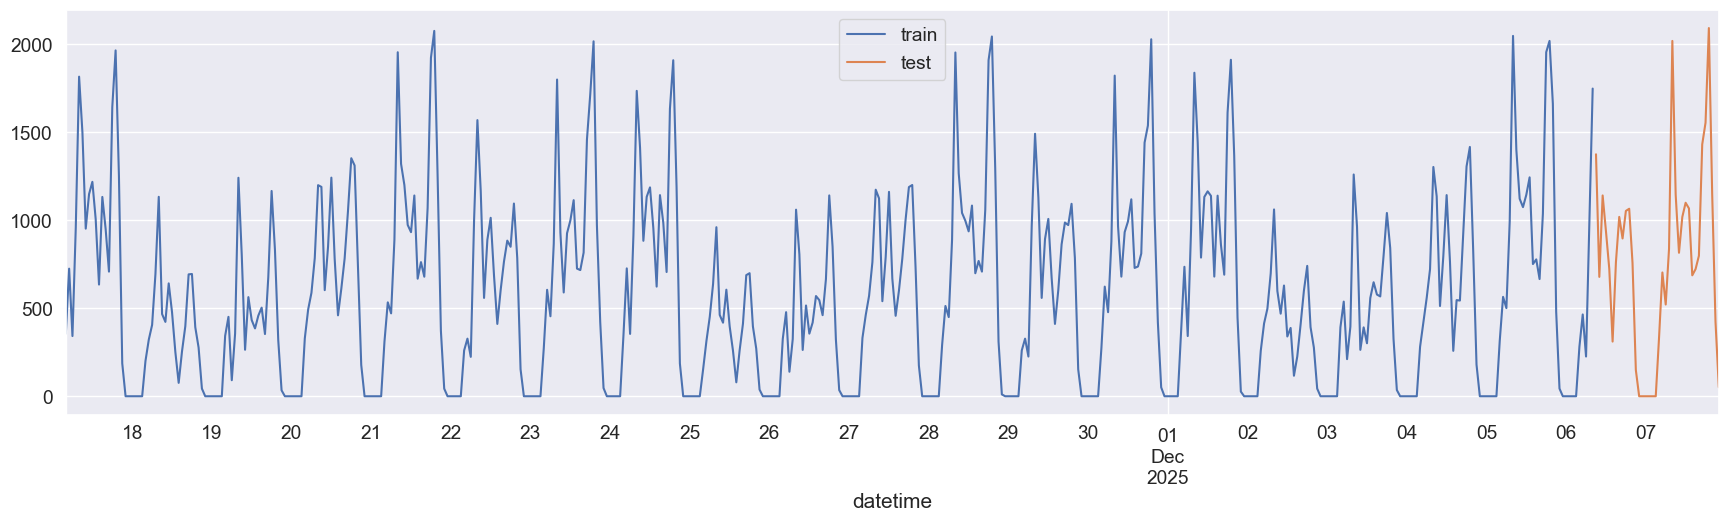

In [55]:
# Separación datos train-test
# ==============================================================================
steps = 38
datos_train = df_mod[:-steps] # desde el inicio hasta 36 pasos anteriores
datos_test  = df_mod[-steps:] # 

print(f"Fechas train : {datos_train.index.min()} --- {datos_train.index.max()}  (n={len(datos_train)})")
print(f"Fechas test  : {datos_test.index.min()} --- {datos_test.index.max()}  (n={len(datos_test)})")

fig, ax = plt.subplots(figsize=(19, 5))
datos_train['real_pax_checkin_adj'].plot(ax=ax, label='train')
datos_test['real_pax_checkin_adj'].plot(ax=ax, label='test')
ax.legend();

<Axes: xlabel='datetime'>

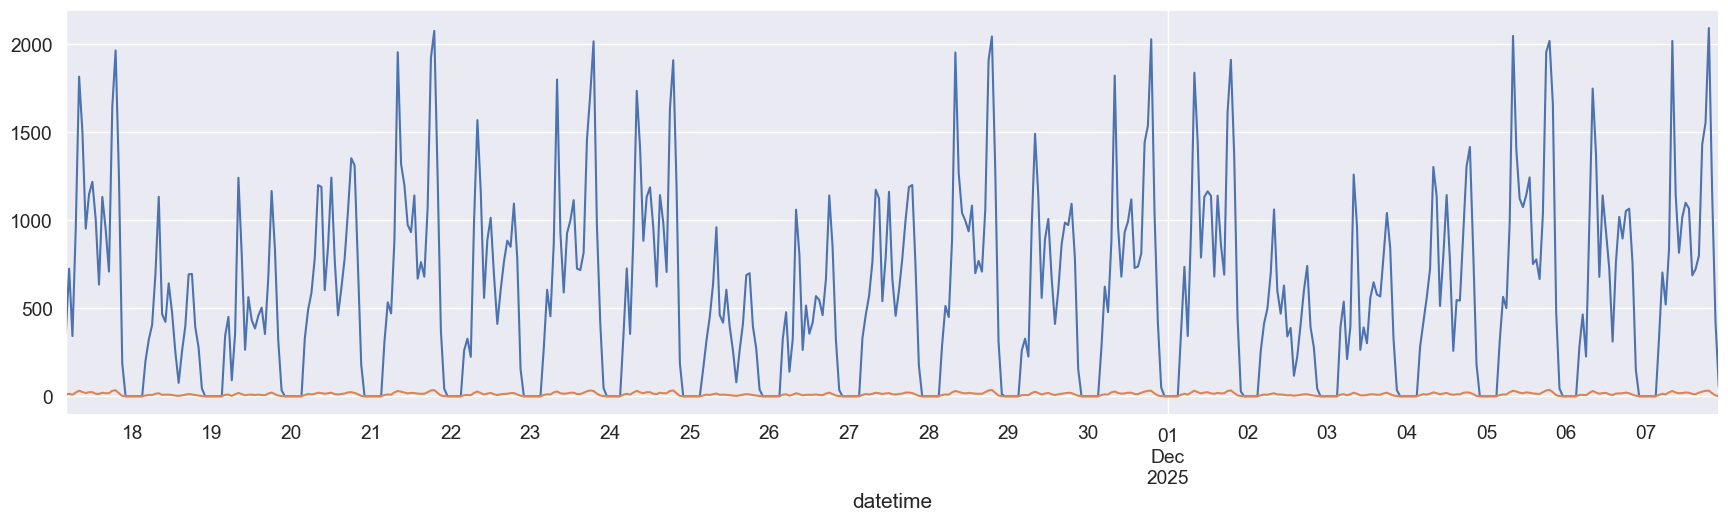

In [56]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['active_flt_2h'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

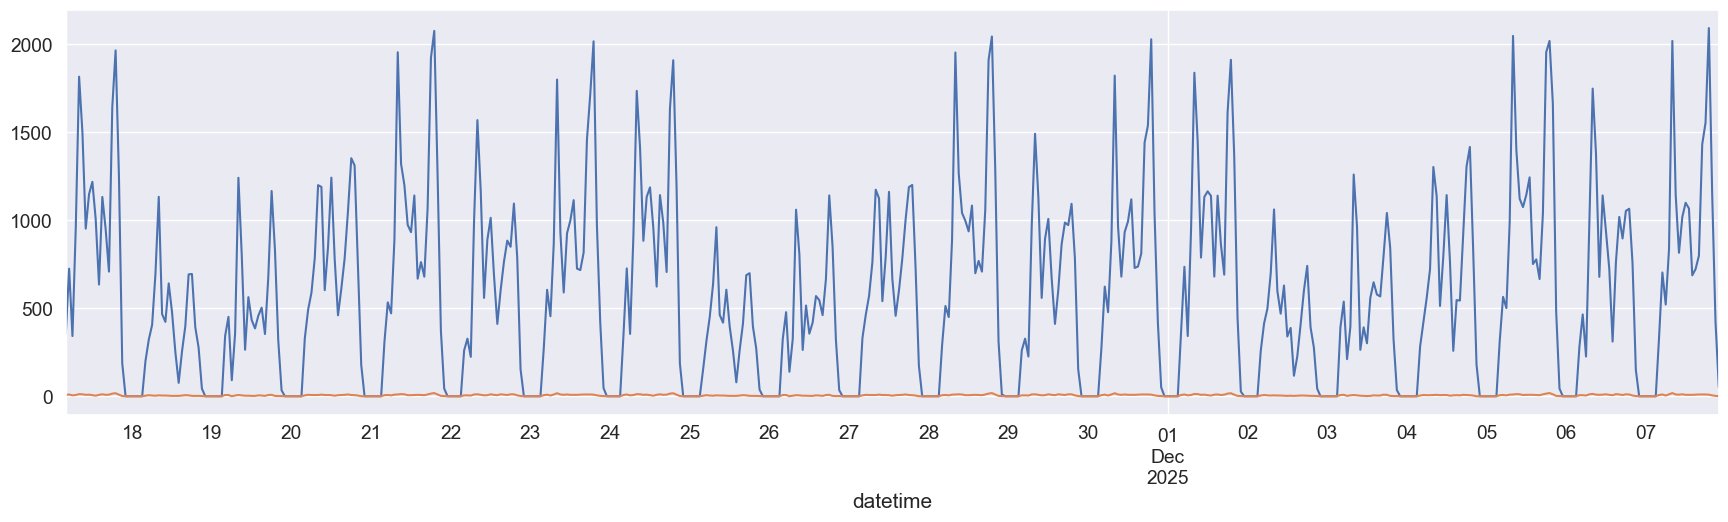

In [57]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['Group_Ryanair'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

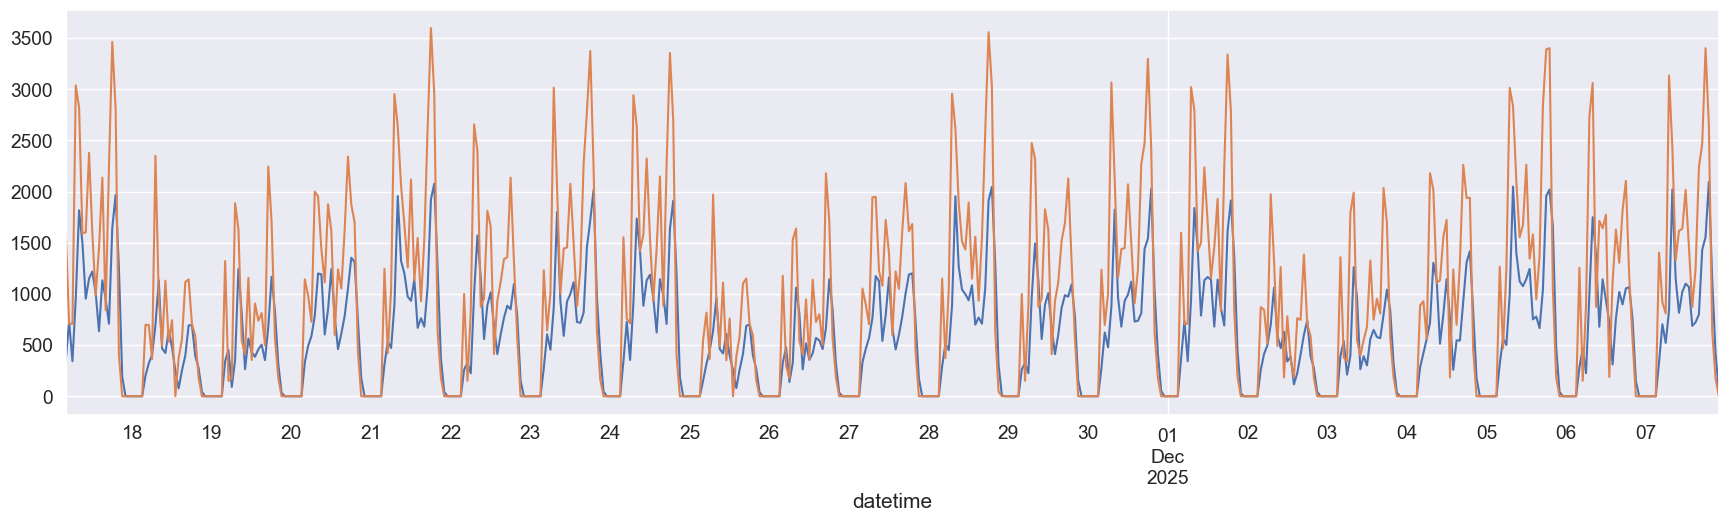

In [58]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['tot_pax'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

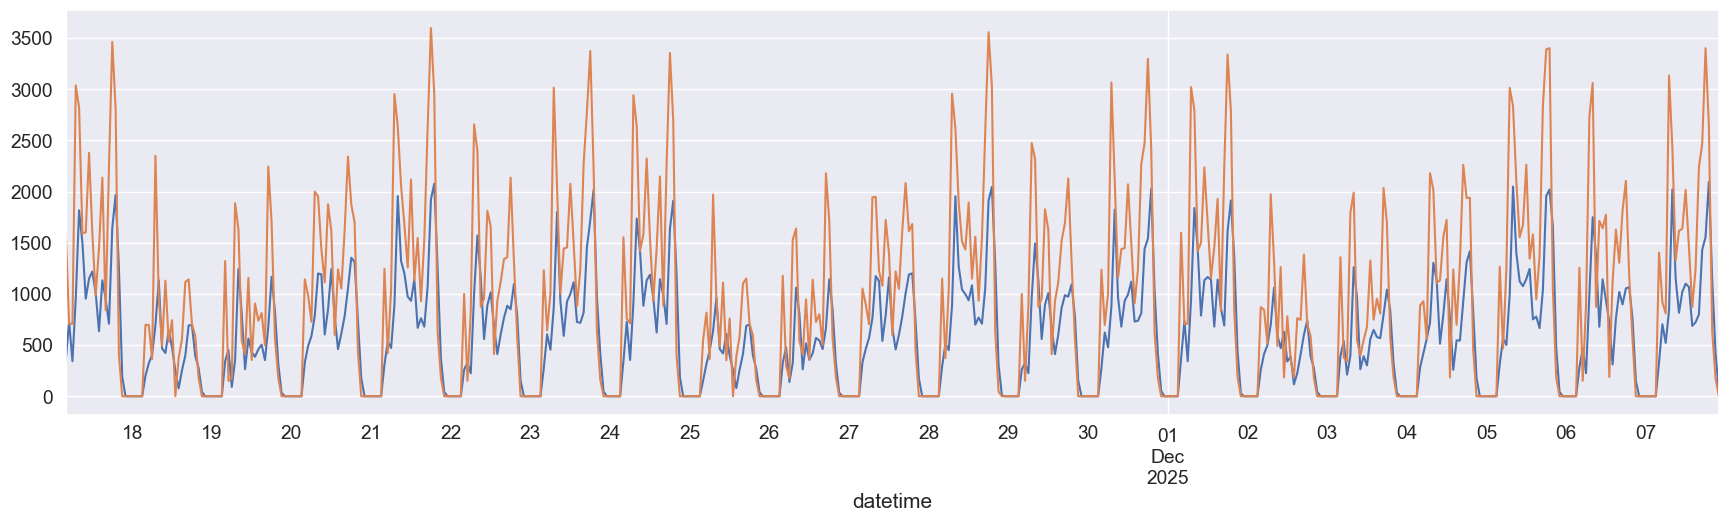

In [59]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['tot_pax'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

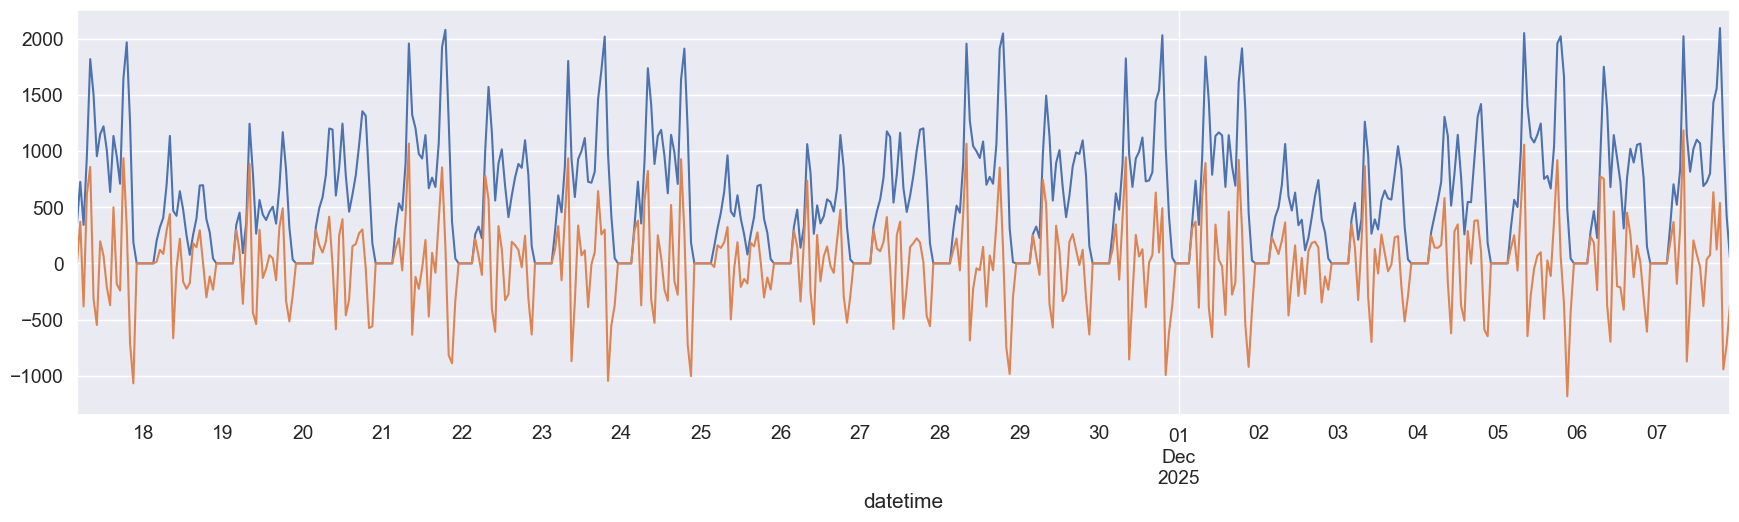

In [60]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['pax_momentum'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

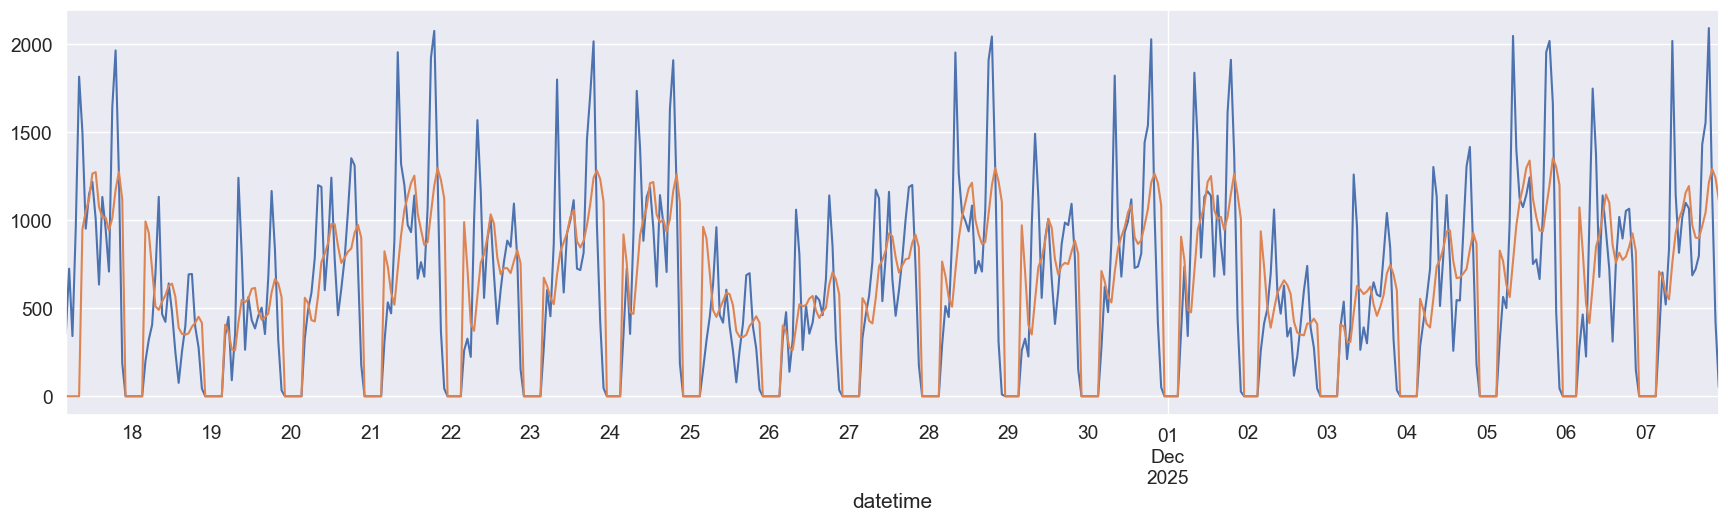

In [61]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['pax_roll_mean_6h'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

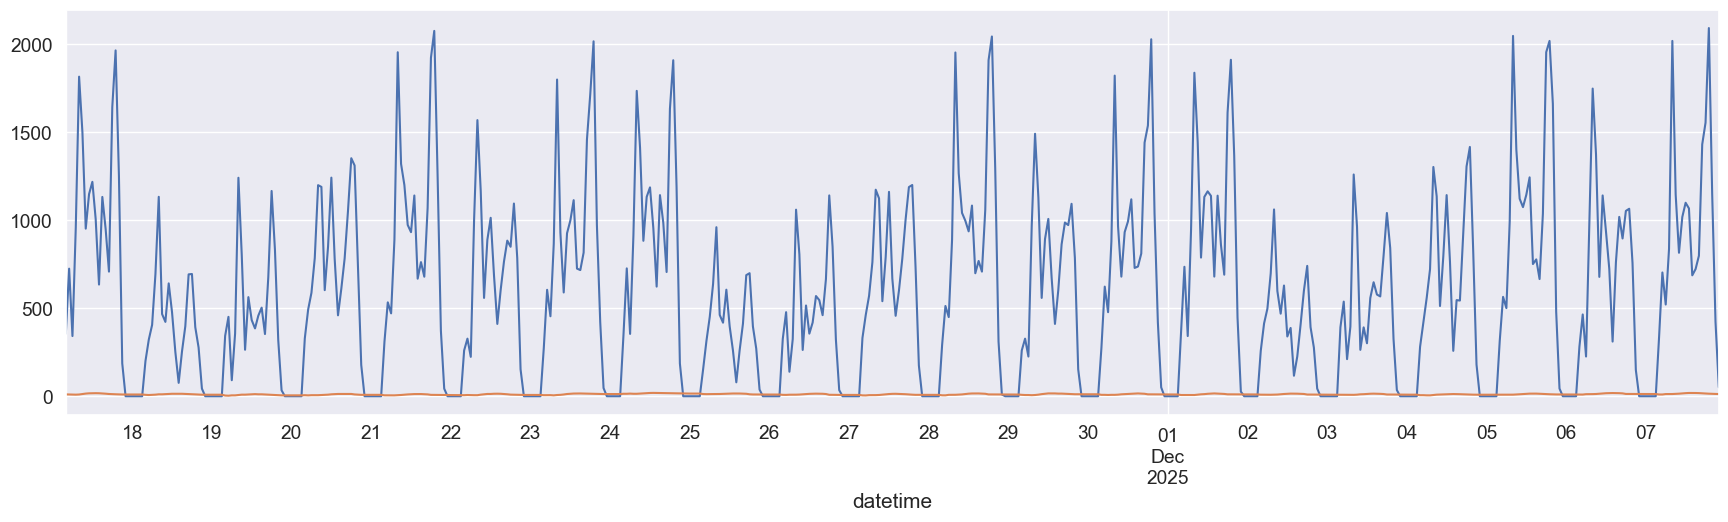

In [62]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['temperatura'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

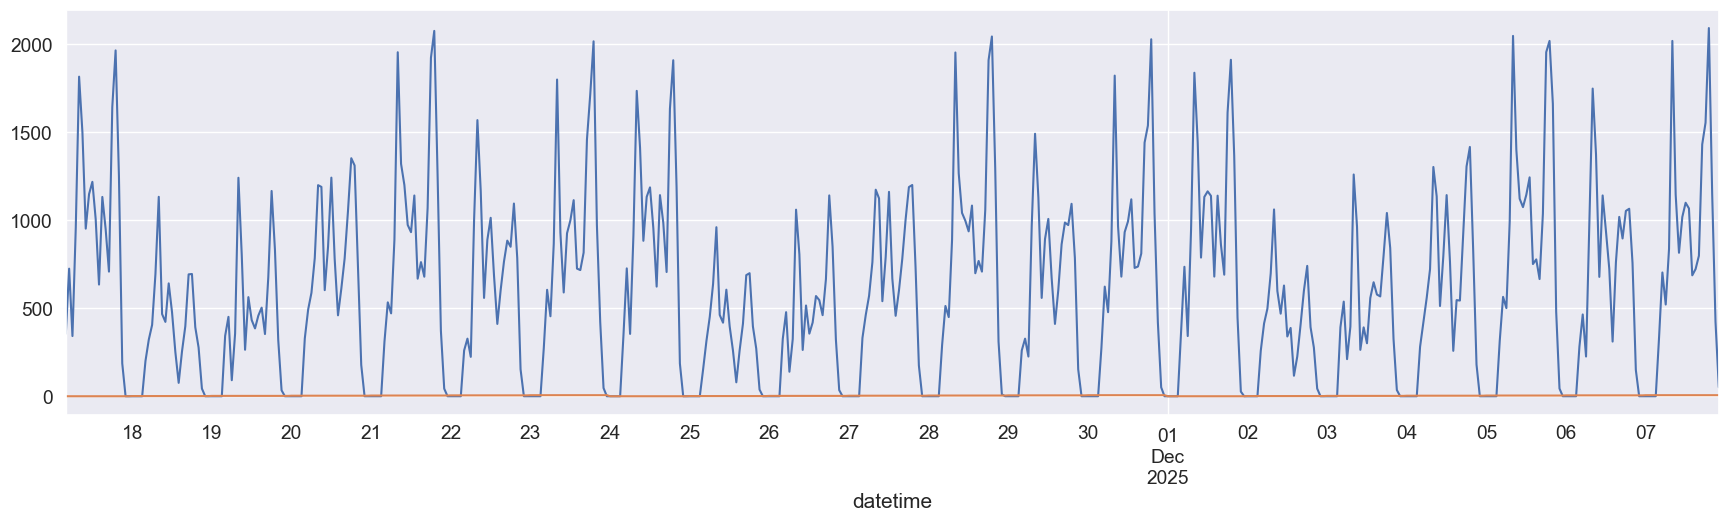

In [63]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_checkin_adj'].plot(ax=ax, label='y')
df_mod['weekday_num'].plot(ax=ax, label='variable exógena')

In [64]:
exogena =['pax_momentum','pax_roll_mean_6h','Visp_fest',
         'temperatura','v_viento','weekday_num','no_vuelos',
          'is_morning','is_evening','is_night', 'festivo']
# estado_clima, 'active_flt_2h' mucha correlacion casi del 90 y pico 
#'Group_Ryanair', 'tot_pax','no_vuelos',
#'EU_flt','NAC_flt','INT_flt' festivo

In [65]:
forecaster = ForecasterRecursive(
    regressor = RandomForestRegressor(
        n_estimators=80,
        max_depth=4,
        min_samples_split=8, # numero minimo de muestras dividir 
        min_samples_leaf=4, 
        max_features=0.5,
        random_state=123),
    lags = [1,3, 6,12, 24])

# VARIABLES EXOGENAS 
#features = [col for col in df_mod.columns if col != "real_pax_checkin_adj"]

forecaster.fit(
    y = datos_train["real_pax_checkin_adj"],
    exog = datos_train[exogena]
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  3  6 12 24] 
Window features: None 
Window size: 24 
Exogenous included: True 
Exogenous names: 
    pax_momentum, pax_roll_mean_6h, Visp_fest, temperatura, v_viento, weekday_num,
    no_vuelos, is_morning, is_evening, is_night, festivo 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2025-11-17 04:00:00'), Timestamp('2025-12-06 08:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: h 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    4, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 8,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 80,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-02-04 18:51:50 
Last fit date: 2026-02-04 18:51:50 
Skforecast version: 0.14.0 
Python version: 3.10.19 
Forecaster id: None

In [66]:
steps = 38 #predice los próximos 36 valores futuros de tu serie
predicciones = forecaster.predict(steps=steps, exog = datos_test[exogena])
predicciones.head(5)

2025-12-06 09:00:00    1140.206367
2025-12-06 10:00:00     883.102281
2025-12-06 11:00:00    1219.926428
2025-12-06 12:00:00     978.987649
2025-12-06 13:00:00     970.451451
Freq: h, Name: pred, dtype: float64

In [67]:
impotancia = forecaster.get_feature_importances()
impotancia

,feature,importance
4,lag_24,0.308538
0,lag_1,0.277324
5,pax_momentum,0.160940
6,pax_roll_mean_6h,0.137648
11,no_vuelos,0.038650
3,lag_12,0.032540
14,is_night,0.019189
1,lag_3,0.012770
10,weekday_num,0.006359
2,lag_6,0.003983


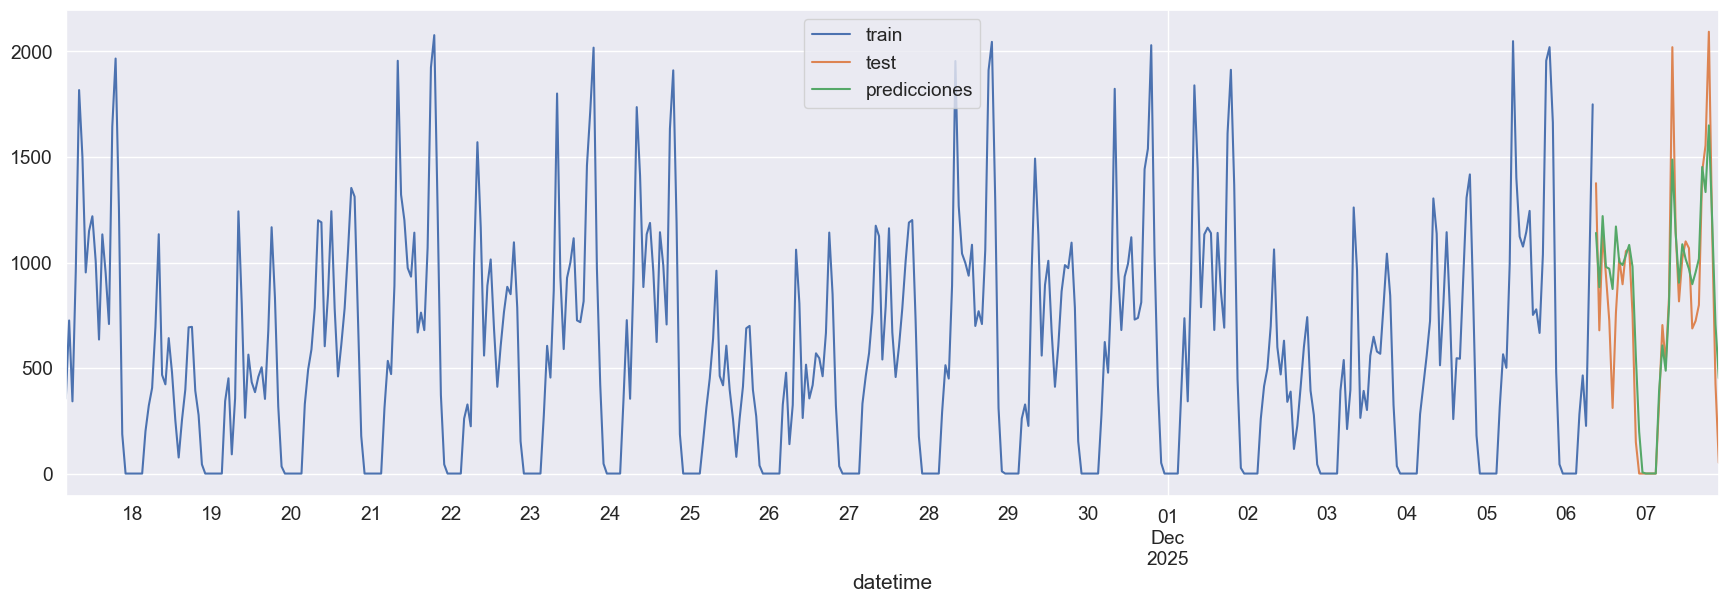

In [68]:
# Gráfico
# ==============================================================================
fig, ax = plt.subplots(figsize=(19, 6))
datos_train['real_pax_checkin_adj'].plot(ax=ax, label='train')
datos_test['real_pax_checkin_adj'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend();

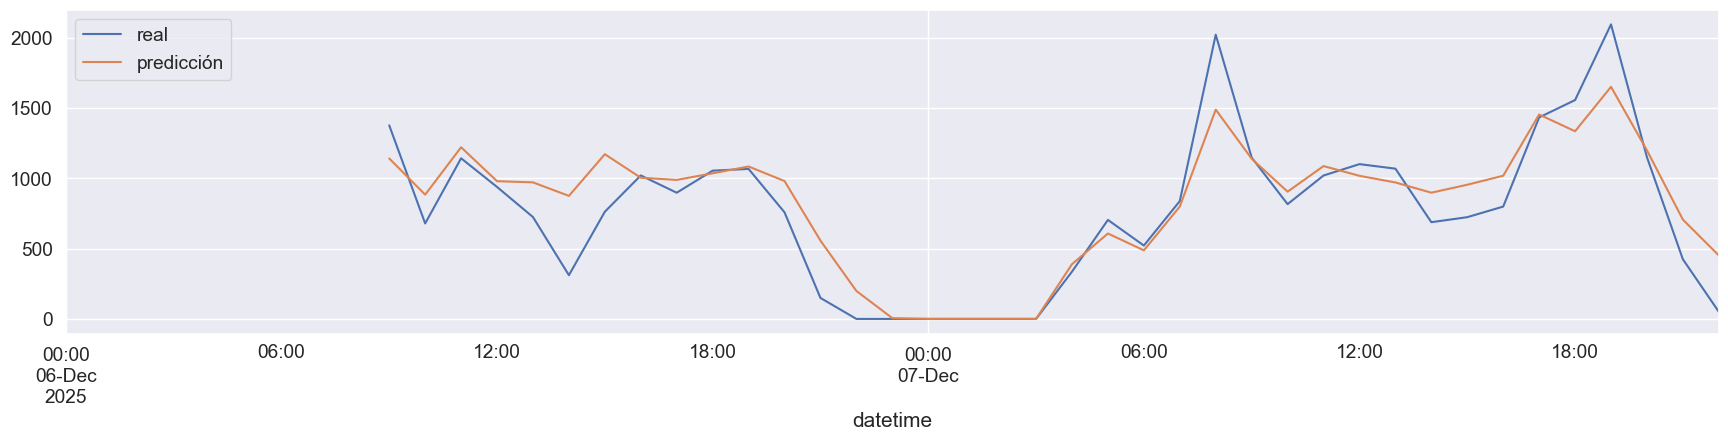

In [69]:
fig, ax = plt.subplots(figsize=(19, 4))

datos_test['real_pax_checkin_adj'].plot(ax=ax, label='real')
predicciones.plot(ax=ax, label='predicción')

ax.set_xlim(pd.Timestamp("2025-12-06"), pd.Timestamp("2025-12-07 22:00"))
ax.legend()
ax.grid(True)
plt.show()


#### Tendencia a sobreestimar el sabado y el domingo infraestimar.

In [70]:
# Error test
# ==============================================================================
error_mse = mean_squared_error(
                y_true = datos_test['real_pax_checkin_adj'],
                y_pred = predicciones
            )

print(f"Error de test (mse): {error_mse}")

Error de test (mse): 49369.95058934769


In [71]:
# Error test
# ==============================================================================
error_rmse = root_mean_squared_error(
                y_true = datos_test['real_pax_checkin_adj'],
                y_pred = predicciones
            )

print(f"Error de test (rmse): {error_rmse}")

# 104.59034436020629 error promedio en la unidad original (pax)
# se equicox en la prediccion de afluencia por hora en un promedio de 148 personas
# promedio de personas es 973.99 con una rmse de 148,35 -> error es 15,23%
# 143 mejorado  
# 141 mejorado 
# 137 mejorado  14% error 
# 286 (al quitar exogenos int,eu, nac)
# 281  (al añadir  lag 8 )
# 140,34 -> 14,40%

# grafico error 

Error de test (rmse): 222.19349808072172


In [72]:
# Error test
# ==============================================================================
error_r2 = r2_score(
                y_true = datos_test['real_pax_checkin_adj'],
                y_pred = predicciones
            )

print(f"Error de test (r2): {error_r2}")

# 0.9731405079192047 
# explica el 94% 
# 95%
# 0,79% 
# 0.80%
# 0.95% 

Error de test (r2): 0.8257620122624089


In [73]:
"""
# 1. Obtener las predicciones sobre el mismo conjunto de entrenamiento
# Nota: La documentación de skforecast indica que este método no requiere 'exog'
# si 'exog' fue usado durante el entrenamiento.
predicciones_train = forecaster.get_train_predict() 

# 2. Calcular el error (ya no hay problema de dimensiones)
error_mset = mean_squared_error(
    y_true = datos_train['real_pax_checkin_adj'],
    y_pred = predicciones_train
)

print(f"Error de entrenamiento (mse): {error_mset}"
"""

'\n# 1. Obtener las predicciones sobre el mismo conjunto de entrenamiento\n# Nota: La documentación de skforecast indica que este método no requiere \'exog\'\n# si \'exog\' fue usado durante el entrenamiento.\npredicciones_train = forecaster.get_train_predict() \n\n# 2. Calcular el error (ya no hay problema de dimensiones)\nerror_mset = mean_squared_error(\n    y_true = datos_train[\'real_pax_checkin_adj\'],\n    y_pred = predicciones_train\n)\n\nprint(f"Error de entrenamiento (mse): {error_mset}"\n'

In [74]:
from skforecast.model_selection import backtesting_forecaster
"""
initial_train_size_value = int(len(datos_train) * 0.7)

metric, predictions = backtesting_forecaster(
    forecaster       = forecaster,
    y                = datos_train["real_pax_checkin_adj"],
    exog             = datos_train[exogena],
    initial_train_size = initial_train_size_value,
    steps            = 36,
    metric           = 'mean_absolute_error'
)
"""

'\ninitial_train_size_value = int(len(datos_train) * 0.7)\n\nmetric, predictions = backtesting_forecaster(\n    forecaster       = forecaster,\n    y                = datos_train["real_pax_checkin_adj"],\n    exog             = datos_train[exogena],\n    initial_train_size = initial_train_size_value,\n    steps            = 36,\n    metric           = \'mean_absolute_error\'\n)\n'

In [118]:
# Grid search de hiperparámetros
# ==============================================================================
forecaster = ForecasterRecursive(
                 regressor = RandomForestRegressor(random_state=123),
                 lags      = 12 # This value will be replaced in the grid search
             )
#hiperparametrizacion con el cross validacion 
# Training and validation folds
cv = TimeSeriesFold(
      steps              = 38,
      initial_train_size = int(len(datos_train) * 0.5),
      refit              = False,
      fixed_train_size   = False,

    )

# Candidate values for lags
lags_grid = [2, 20]

# Candidate values for regressor's hyperparameters
param_grid = {
    'n_estimators': [40,50,60,80,90],
    'max_depth': [3,4,6,7,9],
    'min_samples_split':[5,6,7,8],
    'min_samples_leaf':[3,4,5,6]
}

resultados_grid = grid_search_forecaster(
                    forecaster  = forecaster,
                    y           = datos_train['real_pax_checkin_adj'],
                    cv          = cv,
                    exog        = datos_train[exogena],
                    param_grid  = param_grid,
                    lags_grid   = lags_grid,
                    metric      = 'mean_squared_error',  
                    return_best = True,
                    n_jobs      = 'auto',
                    verbose     = False
                )

lags grid: 100%|██████████████████████████| 2/2 [05:47<00:00, 173.92s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2] 
  Parameters: {'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 60}
  Backtesting metric: 18434.417752756694


In [76]:
resultados_grid

,lags,lags_label,params,mean_squared_error,max_depth,min_samples_leaf,min_samples_split,n_estimators
0,"[1, 2]","[1, 2]","{'max_depth': 10, 'min_samples_leaf': 3, 'min_...",18427.091303,10,3,7,60
1,"[1, 2]","[1, 2]","{'max_depth': 9, 'min_samples_leaf': 3, 'min_s...",18434.417753,9,3,7,60
2,"[1, 2]","[1, 2]","{'max_depth': 10, 'min_samples_leaf': 3, 'min_...",18487.901400,10,3,7,100
3,"[1, 2]","[1, 2]","{'max_depth': 9, 'min_samples_leaf': 3, 'min_s...",18537.947170,9,3,7,100
4,"[1, 2]","[1, 2]","{'max_depth': 9, 'min_samples_leaf': 3, 'min_s...",18550.676503,9,3,5,100
...,...,...,...,...,...,...,...,...
1435,"[1, 2]","[1, 2]","{'max_depth': 3, 'min_samples_leaf': 3, 'min_s...",69716.317923,3,3,10,40
1436,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 3, 'min_samples_leaf': 3, 'min_s...",69723.316652,3,3,7,90
1437,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 3, 'min_samples_leaf': 3, 'min_s...",69759.952316,3,3,8,90
1438,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 3, 'min_samples_leaf': 3, 'min_s...",69790.086018,3,3,6,90


In [170]:
# Crear y entrenar forecaster con mejores hiperparámetros
# ==============================================================================

regressor = RandomForestRegressor(n_estimators=60, 
                                  max_depth=10, 
                                  min_samples_split=6, # numero minimo de muestras dividir 
                                  min_samples_leaf=3, 
                                  max_features=0.5, 
                                  random_state=123)

forecaster = ForecasterRecursive(
                 regressor = regressor,
                 lags      = [1,2],
             )
#forecaster.fit(y=datos_train['real_pax_checkin_adj'])
forecaster.fit(y=datos_train['real_pax_checkin_adj'], exog = datos_train[exogena])


In [171]:
# Predicciones
# ==============================================================================
predicciones = forecaster.predict(steps=steps, exog = datos_test[exogena])
predicciones.head(5)

2025-12-06 09:00:00    1203.616046
2025-12-06 10:00:00     640.637168
2025-12-06 11:00:00    1118.680151
2025-12-06 12:00:00     907.167383
2025-12-06 13:00:00     852.544014
Freq: h, Name: pred, dtype: float64

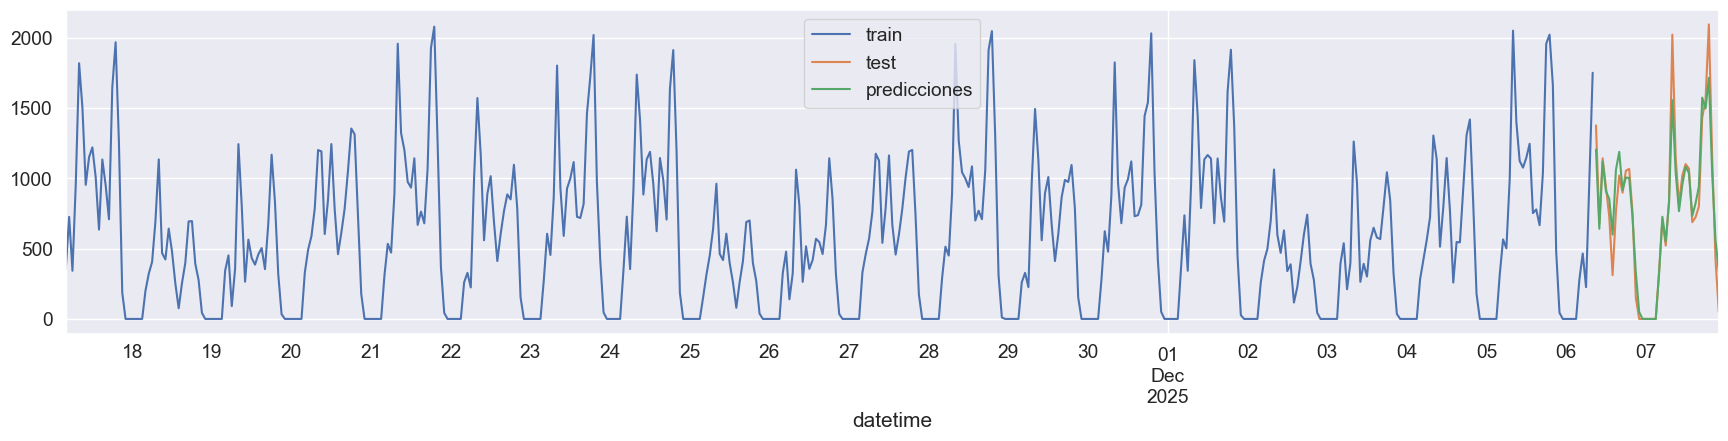

In [172]:
# Gráfico
# ==============================================================================
fig, ax = plt.subplots(figsize=(19, 4))
datos_train['real_pax_checkin_adj'].plot(ax=ax, label='train')
datos_test['real_pax_checkin_adj'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend();

Test zoom: (38, 24)
Pred zoom: (38,)


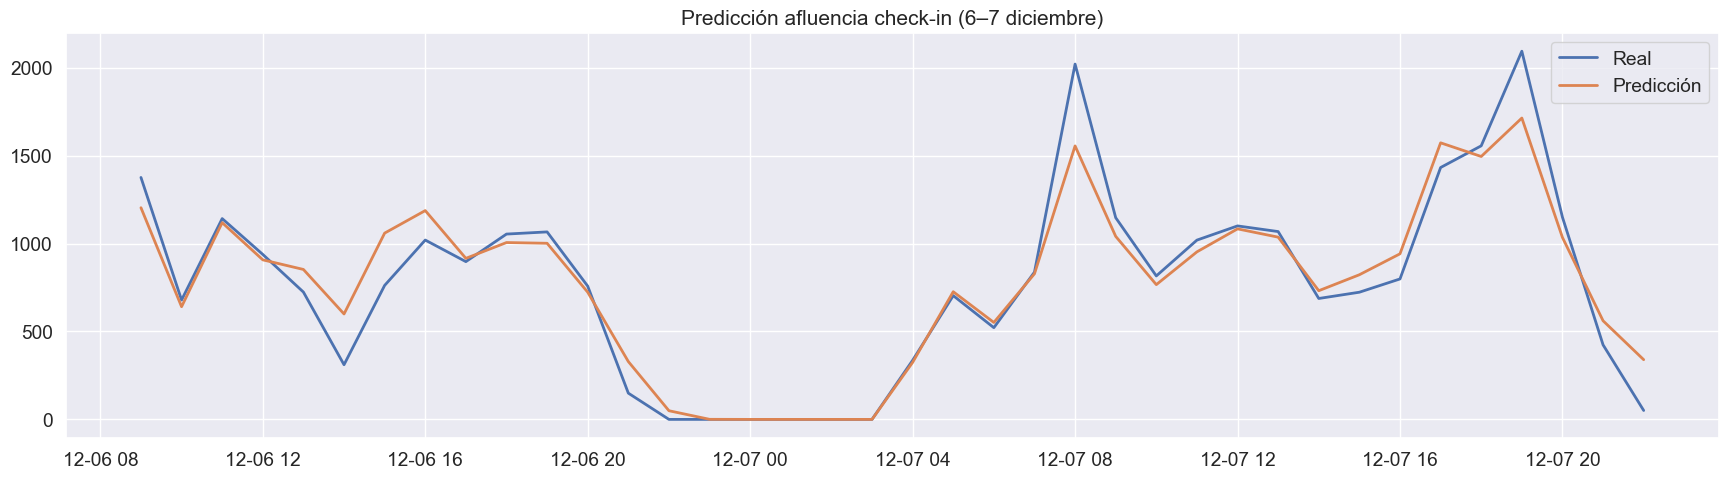

In [173]:
predicciones.index = pd.to_datetime(predicciones.index)
datos_test.index   = pd.to_datetime(datos_test.index)


inicio = pd.Timestamp("2025-12-06 09:00")
fin    = pd.Timestamp("2025-12-07 22:00")

test_zoom = datos_test.loc[inicio:fin]
pred_zoom = predicciones.loc[inicio:fin]

print("Test zoom:", test_zoom.shape)
print("Pred zoom:", pred_zoom.shape)

fig, ax = plt.subplots(figsize=(19, 5))

if len(test_zoom) > 0:
    ax.plot(test_zoom.index, 
            test_zoom['real_pax_checkin_adj'], 
            label="Real", 
            linewidth=2)

if len(pred_zoom) > 0:
    ax.plot(pred_zoom.index, 
            pred_zoom.values, 
            label="Predicción", 
            linewidth=2)

ax.set_title("Predicción afluencia check-in (6–7 diciembre)")
ax.legend()
ax.grid(True)
plt.show()


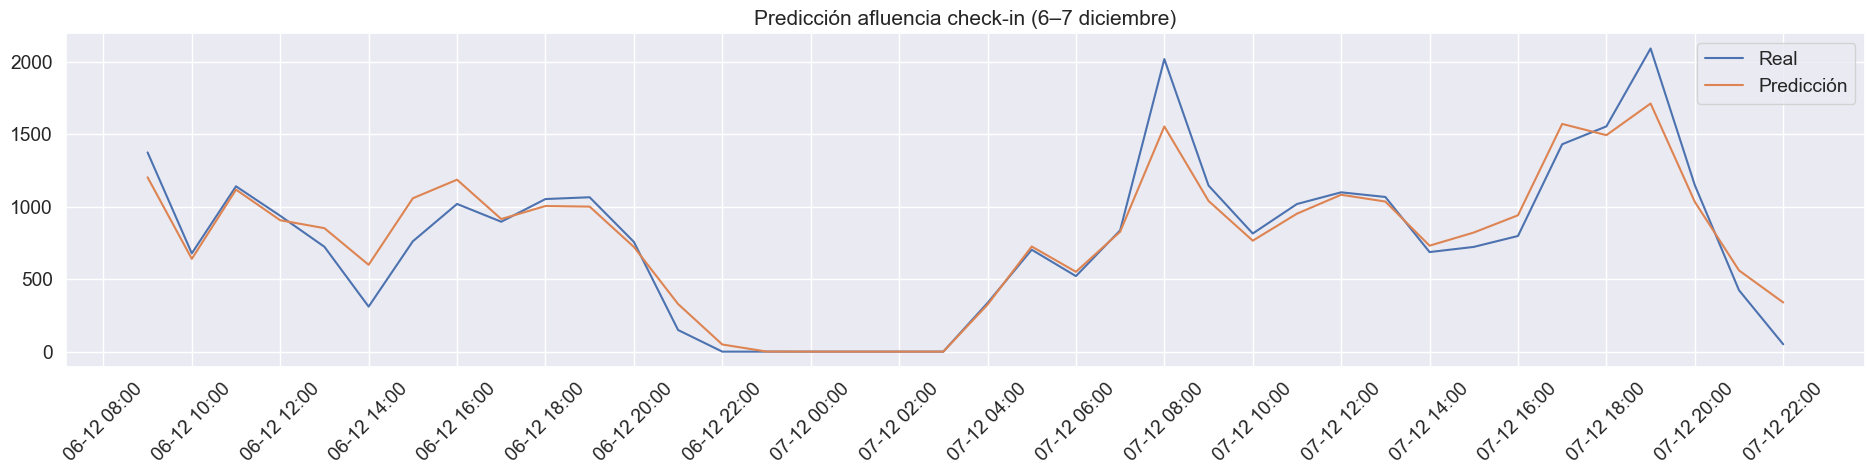

In [174]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(19, 5))

ax.plot(test_zoom.index, test_zoom['real_pax_checkin_adj'], label="Real")
ax.plot(pred_zoom.index, pred_zoom.values, label="Predicción")

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))

ax.set_title("Predicción afluencia check-in (6–7 diciembre)")
ax.legend()
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [175]:
df_eval = test_zoom.copy()
df_eval["pred"] = pred_zoom.values
df_eval["error"] = df_eval["real_pax_checkin_adj"] - df_eval["pred"]
df_eval["abs_error"] = df_eval["error"].abs()
df_eval["hora"] = df_eval.index.hour


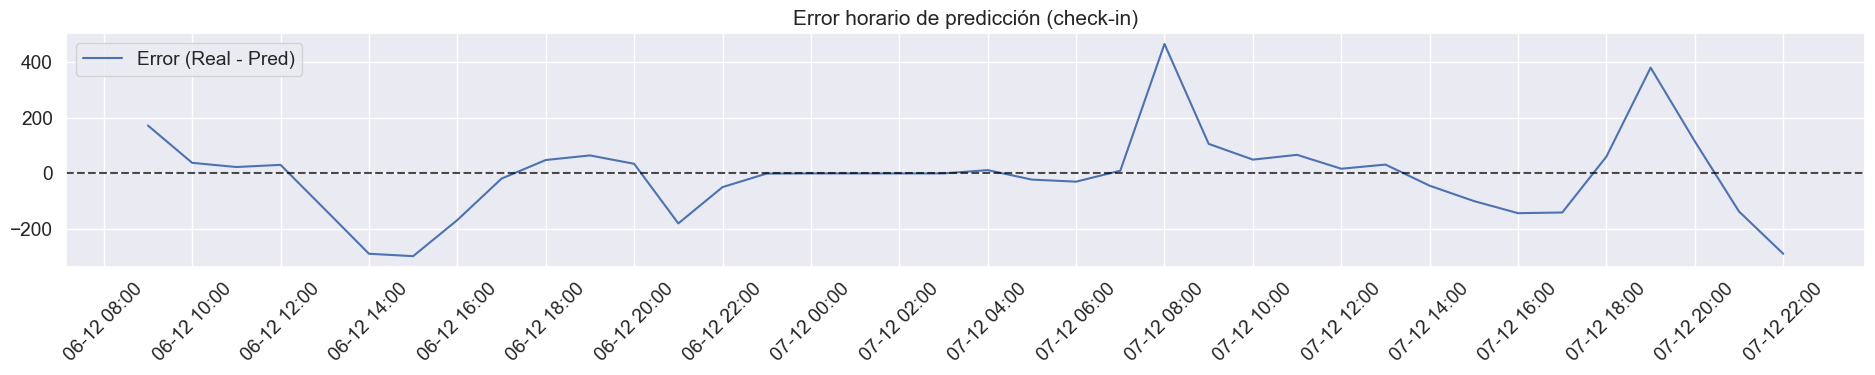

In [176]:
fig, ax = plt.subplots(figsize=(19, 4))

ax.plot(df_eval.index, df_eval["error"], label="Error (Real - Pred)")
ax.axhline(0, color="black", linestyle="--", alpha=0.7)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))

ax.set_title("Error horario de predicción (check-in)")
ax.legend()
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Error positivo** → infraestima (llega más gente de lo previsto) a las 8:00 estimo que llega x cantidad de pax, pero la realidad es que hay más. 

**Error negativo** → sobreestima  (llega menos gente de lo previsto) a las 14:00 estimo que hay x pasajeros pero en realidad hay menos. 

**Picos grandes** → horas donde el modelo falla más a las[ 8-9, 14 y 18-19 ]
- A la 8-9 estima que llega menos pax de la realidad.
- 14 estima que llega más pax de la realidad
- 18-19 estima que llega menos pax de la realidad. 

Resumen: El modelo capta bien la tendencia general, pero presenta mayor error en horas punta.

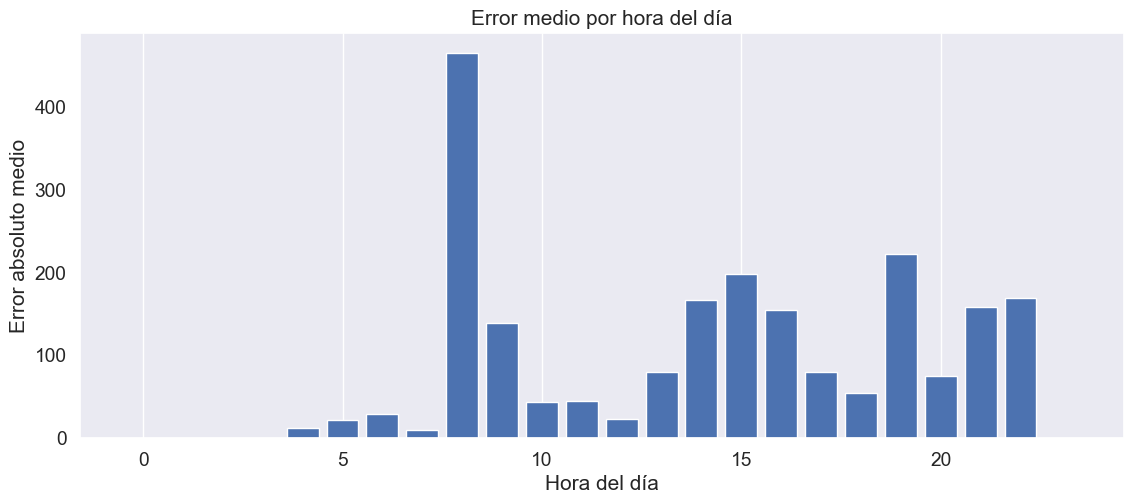

In [177]:
error_por_hora = (
    df_eval
    .groupby("hora")["abs_error"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.bar(error_por_hora["hora"], error_por_hora["abs_error"])
plt.xlabel("Hora del día")
plt.ylabel("Error absoluto medio")
plt.title("Error medio por hora del día")
plt.grid(axis="y")
plt.show()


In [178]:
error_por_hora.sort_values("abs_error", ascending=False).head(5)


,hora,abs_error
8,8,465.196075
19,19,222.302558
15,15,198.309794
22,22,169.001847
14,14,166.379656


EL MODELO PREDICE PEOR EN 

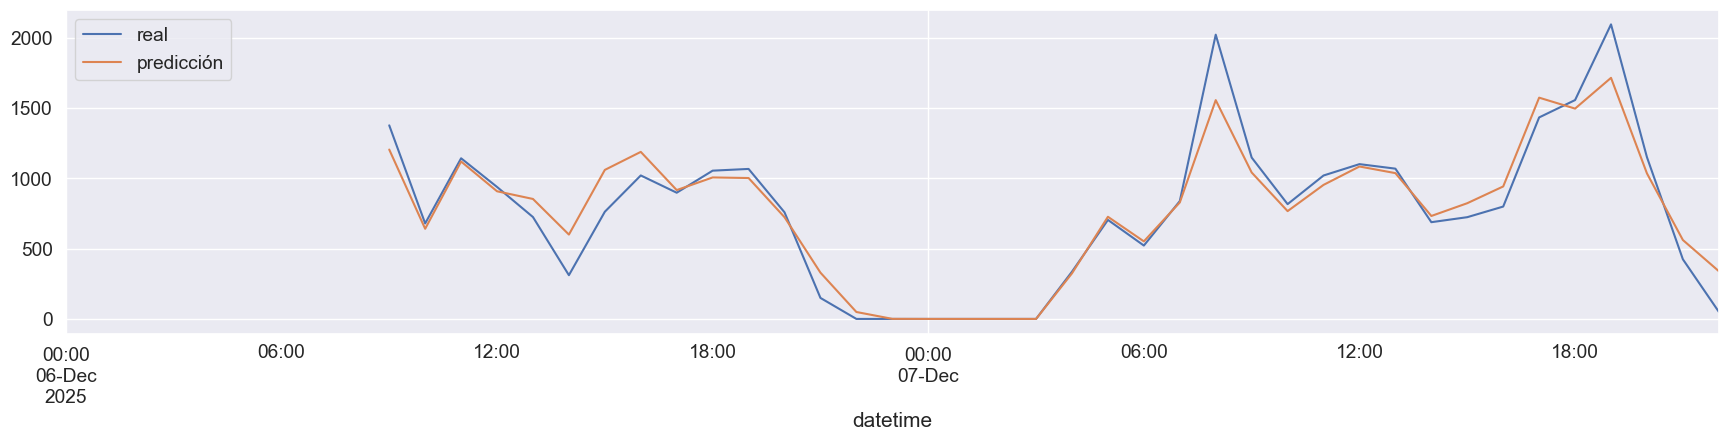

In [179]:
fig, ax = plt.subplots(figsize=(19, 4))

datos_test['real_pax_checkin_adj'].plot(ax=ax, label='real')
predicciones.plot(ax=ax, label='predicción')

ax.set_xlim(pd.Timestamp("2025-12-06"), pd.Timestamp("2025-12-07 22:00"))
ax.legend()
ax.grid(True)
plt.show()


In [180]:
 # grafico ciclico durante 1 dia (24)

In [181]:
# Error de test
# ==============================================================================
error_mse = mean_squared_error(
                y_true = datos_test['real_pax_checkin_adj'],
                y_pred = predicciones
            )

print(f"Error de test (mse) {error_mse}")

Error de test (mse) 22221.139154950142


In [185]:
# Error test
# ==============================================================================
error_rmse = root_mean_squared_error(
                y_true = datos_test['real_pax_checkin_adj'],
                y_pred = predicciones
            )

print(f"Error de test (rmse): {error_rmse}")

Error de test (rmse): 149.06756573765517


In [186]:
# Error test
# ==============================================================================
error_r2 = r2_score(
                y_true = datos_test['real_pax_checkin_adj'],
                y_pred = predicciones
            )

print(f"Error de test (r2): {error_r2}")

# 0.9731405079192047 
# explica el 94% 
# 95%
# 0,79% 
# 0.80%

Error de test (r2): 0.9215764543942869


In [187]:
#Entrenado con el test restante antes de guardar 

GUARDAR PREDICCIÓN: 

In [188]:
forecaster_f = ForecasterRecursive(
                 regressor = regressor,
                 lags      = 20,
             )
forecaster_f.fit(y=df_mod['real_pax_checkin_adj'],exog = df_mod[exogena])

In [189]:
save_forecaster(forecaster_f, file_name='forecasterDIC.joblib', verbose=False)

In [190]:
df_mod['real_pax_checkin_adj'].describe() # bajo 60 , medio 415, alto 750

count     499.000000
mean      602.619439
std       525.342892
min         0.000000
25%        48.440000
50%       544.110000
75%       962.513333
max      2093.353333
Name: real_pax_checkin_adj, dtype: float64

In [191]:
df_pred = pd.DataFrame({
    'datetime': predicciones.index,
    'pred_checkin': predicciones.values
})
df_pred

,datetime,pred_checkin
0,2025-12-06 09:00:00,1203.616046
1,2025-12-06 10:00:00,640.637168
2,2025-12-06 11:00:00,1118.680151
3,2025-12-06 12:00:00,907.167383
4,2025-12-06 13:00:00,852.544014
5,2025-12-06 14:00:00,599.413697
6,2025-12-06 15:00:00,1059.100903
7,2025-12-06 16:00:00,1187.240797
8,2025-12-06 17:00:00,915.614770
9,2025-12-06 18:00:00,1005.526226


In [192]:
df_pred['pred_checkin'].mean()

np.float64(780.683608840688)

In [193]:
df_pred['pred_checkin'].max()

np.float64(1713.3909710631192)

In [194]:
df_pred.shape

(38, 2)

In [195]:
df_pred['datetime'].unique()

<DatetimeArray>
['2025-12-06 09:00:00', '2025-12-06 10:00:00', '2025-12-06 11:00:00',
 '2025-12-06 12:00:00', '2025-12-06 13:00:00', '2025-12-06 14:00:00',
 '2025-12-06 15:00:00', '2025-12-06 16:00:00', '2025-12-06 17:00:00',
 '2025-12-06 18:00:00', '2025-12-06 19:00:00', '2025-12-06 20:00:00',
 '2025-12-06 21:00:00', '2025-12-06 22:00:00', '2025-12-06 23:00:00',
 '2025-12-07 00:00:00', '2025-12-07 01:00:00', '2025-12-07 02:00:00',
 '2025-12-07 03:00:00', '2025-12-07 04:00:00', '2025-12-07 05:00:00',
 '2025-12-07 06:00:00', '2025-12-07 07:00:00', '2025-12-07 08:00:00',
 '2025-12-07 09:00:00', '2025-12-07 10:00:00', '2025-12-07 11:00:00',
 '2025-12-07 12:00:00', '2025-12-07 13:00:00', '2025-12-07 14:00:00',
 '2025-12-07 15:00:00', '2025-12-07 16:00:00', '2025-12-07 17:00:00',
 '2025-12-07 18:00:00', '2025-12-07 19:00:00', '2025-12-07 20:00:00',
 '2025-12-07 21:00:00', '2025-12-07 22:00:00']
Length: 38, dtype: datetime64[ns]

In [196]:
df_pred["hora"] = df_pred["datetime"].dt.hour
df_pred["fecha"] = df_pred["datetime"].dt.date
df_pred["weekday"] = df_pred["datetime"].dt.weekday


In [197]:
#df_pred.to_csv("Tabla_aflu_checkin.csv") 

- Ridge Regression
- Random Forest (suave)

In [198]:
# MODELO 2: CONTROL SEGURIDAD:

In [103]:
# MODELO 3: CONTROL PASAPORTE: